## **AI for Epigraphy: Ανάλυση Εικόνων και Κειμένων Αρχαίων Ελληνικών Επιγραφών**


Σε αυτή την εργασία θα σχεδιάσουμε ένα πλήρες υπολογιστικό pipeline για την ανάλυση αρχαίων ελληνικών επιγραφών. Το σύνολο δεδομένων αποτελεί μέρος του ICDAR 2026 Competition in Text Recognition on Greek Squeezes και είναι διαθέσιμο [εδώ](https://www.science.smith.edu/~nhowe/contest/trogs26.html#dataset).

Τα δεδομένα περιλαμβάνουν μεταγραφές κειμένων (λατινικοί χαρακτήρες σε μορφή scriptio continua) και εικόνες επιγραφών (squeezes).

---



In [1]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from collections import Counter
import re
import unicodedata
import json
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import warnings

In [2]:
import os
print(os.listdir("./content"))

annotations_dir = './content/Annotations/Annotations/'
images_dirs = ['./content/Images1/', '/content/Images4/']

ann_files = {f.replace('_letters.txt', '') for f in os.listdir(annotations_dir) if f.endswith('.txt')}

img_ids = set()
for d in images_dirs:
    if os.path.exists(d):
        for f in os.listdir(d):
            if f.endswith('.png'):
                img_ids.add(f.replace('.png', ''))

valid_pairs = ann_files.intersection(img_ids)

print(f"Συνολικά αρχεία κειμένου (Annotations): {len(ann_files)}")
print(f"Συνολικές εικόνες: {len(img_ids)}")
print("-" * 30)
print(f"Σύνολο ζευγαριών: {len(valid_pairs)}")

if valid_pairs:
    print("\nΔείγμα αντιστοιχίσεων:")
    for item in list(valid_pairs)[:5]:
        print(f"ID: {item}")

['Annotations', 'Images1', 'Images1.zip', 'Images4', 'Images4.zip']
Συνολικά αρχεία κειμένου (Annotations): 448
Συνολικές εικόνες: 74
------------------------------
Σύνολο ζευγαριών: 74

Δείγμα αντιστοιχίσεων:
ID: IAS33166_Rotation2_300dpi
ID: IAS_27265_Rotation2_300dpi
ID: IG_II2_61_Rotation2_300dpi
ID: IAS33117_Merged_Rotation1_300dpi
ID: IAS_27272_Rotation1_300dpi


### **Α1.** Σύστημα Μεταγραφής από Λατινικούς σε Ελληνικούς Χαρακτήρες

---
Οι μεταγραφές στο dataset παρέχονται σε scriptio continua με λατινικούς χαρακτήρες. Για την μετατροπή των λατινικών χαρακτήρων των μετεγραφώ σε κεφαλαία ελληνικά γράμματα, υλοποιήθηκε ένα σύστημα αντιστοίχησης βασισμένο στο βοηθητικό αρχείο "Proxies" του dataset.

Η υλοποίηση βασίζεται σε δύο βήματα:
1. **Φόρτωση μεταγραφής (load_transcript_clean):** Διαβάζει μόνο το τμήμα # Transcript του κάθε αρχείου .txt, αφαιρεί σύμβολα και ειδικούς χαρακτήρες με την χρήση κανονικών εκφράσεων και επιστρέφει ένα εννιαίο string χωρίς κενά.
2. **Λεξικό Αντιστοίχισης (latin_to_greek_dict):** Χαρτογραφεί κάθε λατινικό χαρακτήρα στο αντίστοιχο κεφαλαίο ελληνικό γράμμα.
3. **Μετατροπή (latin_to_greek):** Διατρέχει το λατινικό κείμενο χαρακτήρα προς χαρακτήρα, μετατρέπει κάθε στοιχείο σε κεφαλαίο και ανακτά την ελληνική του αντιστοίχιση από το λεξικό



In [3]:
import pandas as pd
# dictionary based on Proxies file
latin_to_greek_dict = {'A':'Α', 'B':'Β', 'G':'Γ', 'D':'Δ', 'E':'Ε', 'Z':'Ζ', 'H':'Η', 'Q':'Θ', 'I':'Ι', 'K':'Κ', 'L':'Λ', 'M':'Μ', 'N':'Ν', 'X':'Ξ', 'O':'Ο', 'P':'Π', 'R':'Ρ', 'S':'Σ', 'T':'Τ', 'Y':'Υ', 'F':'Φ', 'C':'Χ', 'U':'Ψ', 'W':'Ω'}

# method to turn latin text to greek
def latin_to_greek(text):
    return "".join([latin_to_greek_dict.get(char.upper(), char) for char in text])
  

# method to read only transcript section
def load_transcript_clean(path):
    lines = []
    keep = False
    with open(path, "r", encoding="utf-8") as file:
        for line in file:
            if "# Transcript" in line:
                keep = True
                continue
            if "# Lines" in line:   
                break
            if keep:
                
                #clean_line = line.replace("*","").replace("\n", "").replace(" ","").strip()
                clean_line = re.sub(r'[^a-zA-Z]', '', line)
                if clean_line:
                    lines.append(clean_line)
                    
    # one string no spaces 
    return "".join(lines)

# translating the annotations
greek_texts = {}
for file in os.listdir(annotations_dir):
    if file.endswith('_letters.txt'):
        path =  os.path.join(annotations_dir, file)
        txt = load_transcript_clean(path)
        greek_txt = latin_to_greek(txt)
        greek_texts[file] = greek_txt
            
# examples

t = list(greek_texts.keys())[:5]
for file in t:
    path = os.path.join(annotations_dir, file)
    txt = load_transcript_clean(path)
    raw = txt[:200]
    greekk = greek_texts[file][:200]
    print("\nFile: ", file)
    print("Latin: \n", txt[:200])
    print("\nGreek: \n", greek_texts[file][:200])    
   # display(make_table(file, raw, greekk))
    print("--" * 60)



File:  Agora_I_4985_Rotation1_300dpi_letters.txt
Latin: 
 STOKAIDIKOSEIHIDIKHTOSENNEAAYTOIDNEANTISASIASEANTODONAIEANPOLEWSAPNIOSAQHNAIPROSILIONMAF

Greek: 
 ΣΤΟΚΑΙΔΙΚΟΣΕΙΗΙΔΙΚΗΤΟΣΕΝΝΕΑΑΥΤΟΙΔΝΕΑΝΤΙΣΑΣΙΑΣΕΑΝΤΟΔΟΝΑΙΕΑΝΠΟΛΕΩΣΑΠΝΙΟΣΑΘΗΝΑΙΠΡΟΣΙΛΙΟΝΜΑΦ
------------------------------------------------------------------------------------------------------------------------

File:  Agora_I_4985_Rotation2_300dpi_letters.txt
Latin: 
 STOKAIDIKOSEIHIDIKHTOSENNEAAYTOIDNEANTISASIASEANTODONAIEANPOLEWSAPNIOSAQHNAIPROSILIONMAF

Greek: 
 ΣΤΟΚΑΙΔΙΚΟΣΕΙΗΙΔΙΚΗΤΟΣΕΝΝΕΑΑΥΤΟΙΔΝΕΑΝΤΙΣΑΣΙΑΣΕΑΝΤΟΔΟΝΑΙΕΑΝΠΟΛΕΩΣΑΠΝΙΟΣΑΘΗΝΑΙΠΡΟΣΙΛΙΟΝΜΑΦ
------------------------------------------------------------------------------------------------------------------------

File:  Agora_I_5477_Rotation1_300dpi_letters.txt
Latin: 
 RCONTOSRISTONIKOSARINHIAGAQHITOYDHMOAQHNAIHQYSIAWSKALLISTIKROISKAIPROSODOSWSPLESDEDOCQAITOISNOMOQETANDEKMERAISPROTERONNAETHKATADIKLHRIANTWITOPOTERWIETEIHWIANHDASQWTAIEGGYHTASLAMBANOENTHKOSTHNPWLEINTHN

Gre

**Σχολιασμός Αποτελεσμάτων**
Η μετατροπή αυτή αποτελεί απαραίτητο βήμα προεπεξεργασίας, καθώς επιτρέπει την εφαρμογή γλωσσικών τεχνικών ανάλυσης πάνω σε ελληνικό κείμενο αντί σε λατινική μεταγραφή.
Το σύστημα εκτελεί με απόλυτη ακρίβεια τη μετατροπή χαρακτήρα προς χαρακτήρα, καθιστώντας το κείμενο άμεσα αναγνώσιμο ως αρχαίο ελληνικό, παρόλο που βρίσκεται σε μορφή scriptio continua.

---

**Α2.** Τμηματοποίηση Λέξεων (Word Segmentation) με Χρήση Πιθανοτικού Μοντέλου

---
Για να αξιολογούμε αν μια υποακολουθία χαρακτήρων είναι έγκυρη ελληνική λέξη, κατασκευάστηκε λεξιλόγιο από το corpus Ericu950/Papyri_1 

**Αλγόριθμος Τμηματοποίησης**
Η τμηματοποίηση πραγματοποιήθηκε με έναν αλγόριθμο Δυναμικού Προγραμματισμού, τον Viterbi, ο οποίος εξετάζει όλες τις δυνατές διασπάσεις ενός συνεχούς κειμένου και επιλέγει εκείνη με τη μεγαλύτερη συνολική πιθανότητα.

Για κάθε πιθανή λέξη:
1. **Έλεγχος Λεξιλογίου:** Ελέγχεται αν η υποακολουθία χαρακτήρων υπάρχει στο λεξικό που δημιουργήθηκε από το corpus.
2. **Υπολογισμός Πιθανότητας:** Αν η λέξη υπάρχει, η πιθανότητά της $P(w)$ υπολογίζεται βάσει της σχετικής συχνότητας εμφάνισής της στο corpus:
   $$P(w) = \frac{\text{Count}(w)}{\text{Total Words}}$$
3. **Υπολογισμός Βαθμολογίας (Score & Smoothing):** Για την αποφυγή underflow, χρησιμοποιείται ο αρνητικός λογάριθμος της πιθανότητας. Για τη διαχείριση των άγνωστων λέξεων (Out-of-Vocabulary - OOV), εφαρμόζεται μια ποινή (penalty) που εξαρτάται από το μήκος της λέξης, ώστε να αποτρέπεται ο κατακερματισμός σε μεμονωμένους χαρακτήρες:
   $$\text{Score}(w) = \begin{cases} 
   -\log P(w), & w \in \text{Vocabulary} \\
   \text{Penalty} \times \text{length}(w), & w \notin \text{Vocabulary}
   \end{cases}$$
4. **Βελτιστοποίηση (Dynamic Programming):** Ο αλγόριθμος Viterbi κατασκευάζει έναν πίνακα επιλογών και, μέσω οπισθοδρόμησης (backtracking), επιλέγει την ακολουθία με το ελάχιστο συνολικό σκορ (μέγιστη πιθανότητα).

Η προσέγγιση αυτή είναι καλύτερη από έναν απλό greedy αλγόριθμο, επειδή λαμβάνει υπόψη ολόκληρη την πρόταση και όχι μόνο την τοπικά καλύτερη επιλογή.

---


In [4]:
from datasets import load_dataset
import re
import unicodedata

print("Loading Paryr_1 dataset..")
ds = load_dataset("Ericu950/Papyri_1", split="train", streaming=True)

# making an ancient greek vocabulary with 30000 words
# finding word frequencies to keep only common words
word_freq = Counter()
for i, item in enumerate(ds.take(30000)):
    text = item.get('Edition_without_brackets', '')
    if text:
        text = text.upper()
        words = re.findall(r'[Α-Ω]+', text)
        for w in words:
            if len(w) > 1:
                word_freq[w] += 1

# keeping words with a frequency>3
ancient_greek_vocab = set()
max_word_length = 0
min_freq = 3

for word, freq in word_freq.items():
    if freq >= min_freq:
        ancient_greek_vocab.add(word)
        if len(word) > max_word_length:
            max_word_length = len(word)

print("Vocab created!")                
print("max word length: {max_word_length} chars")
print(f"Συνολικές μοναδικές λέξεις στο dataset: {len(word_freq)}")
print(f"Λέξεις στο φιλτραρισμένο λεξικό (συχνότητα >= {min_freq}): {len(ancient_greek_vocab)}")


####################################################################

# implementing Viterbi, Dynamic Programming
def segment_viterbi(text, vocab, word_freq, max_len):
    text = text.upper()
    n = len(text)
    total = sum(word_freq.values())

    length_penalty = 5.0
    
    # dp[i] = (best_score, split_point)
    dp = [(float('-inf'), 0)] * (n + 1)
    dp[0] = (0.0, 0)  # empty text has score=0 
    
    for i in range(1, n + 1):
        for length in range(1, min(max_len, i) + 1):
            j = i - length
            word = text[j:i]
            if word in vocab and dp[j][0] > float('-inf'):
                freq = word_freq.get(word, 0)
                if freq == 0:
                    continue  

                prob = freq/total
                base_score = math.log(prob)

                score = dp[j][0] + base_score + (length*length_penalty)
                
                if score > dp[i][0]:
                    dp[i] = (score, j)
    
    # Backtrack
    words = []
    i = n
    while i > 0:
        score, j = dp[i]
        if score == float('-inf') or j == i:
            words.append(text[i-1])
            i -= 1
        else:
            words.append(text[j:i])
            i = j
    
    return " ".join(reversed(words))


##########################################################################
## segmentation ##

raw_latin_texts = {}
greek_continua_texts = {}
segmented_greek_texts = {}

for file in os.listdir(annotations_dir):
    if file.endswith('_letters.txt'):
        path = os.path.join(annotations_dir, file)
        
        # loading latin scriptio continua
        latin_txt = load_transcript_clean(path)
        raw_latin_texts[file] = latin_txt
        
        # transilitating latin to greek scriptio continua
        greek_continua = latin_to_greek(latin_txt)
        greek_continua_texts[file] = greek_continua
        
        # segmentation with viterbi 
        segmented_greek = segment_viterbi(greek_continua, ancient_greek_vocab, word_freq, max_word_length)             
        segmented_greek_texts[file] = segmented_greek

print(f"Η επεξεργασία ολοκληρώθηκε για {len(segmented_greek_texts)} αρχεία!")


#############################################################################
# showing 5 first files
sample_files = list(segmented_greek_texts.keys())[:5]

for file in sample_files:
    print(f"\n Αρχείο: {file}")
    
    #keeping the texts the same length
    latin_sample = raw_latin_texts[file][:60]
    greek_continua_sample = greek_continua_texts[file][:60]
    segmented_sample = segmented_greek_texts[file][:80] # 80 becuse of spaces
    
    # creating a dataframe to present the transliteration
    df_show = pd.DataFrame({
        "Στάδιο Επεξεργασίας": [
            "1. Latin (Scriptio Continua)", 
            "2. Greek (Scriptio Continua)", 
            "3. Greek (Word Segmentation)"
        ],
        "Κείμενο Επιγραφής": [
            latin_sample + "...",
            greek_continua_sample + "...",
            segmented_sample + "..."
        ]
    })
    
    display(df_show)
    print("-" * 50)


Loading Paryr_1 dataset..
Vocab created!
max word length: {max_word_length} chars
Συνολικές μοναδικές λέξεις στο dataset: 137024
Λέξεις στο φιλτραρισμένο λεξικό (συχνότητα >= 3): 38381
Η επεξεργασία ολοκληρώθηκε για 448 αρχεία!

 Αρχείο: Agora_I_4985_Rotation1_300dpi_letters.txt


,Στάδιο Επεξεργασίας,Κείμενο Επιγραφής
0,1. Latin (Scriptio Continua),STOKAIDIKOSEIHIDIKHTOSENNEAAYTOIDNEANTISASIASE...
1,2. Greek (Scriptio Continua),ΣΤΟΚΑΙΔΙΚΟΣΕΙΗΙΔΙΚΗΤΟΣΕΝΝΕΑΑΥΤΟΙΔΝΕΑΝΤΙΣΑΣΙΑΣΕ...
2,3. Greek (Word Segmentation),ΣΤΟ ΚΑΙ ΔΙΚΟΣ ΕΙΗ ΙΔΙ ΚΗΤΟΣ ΕΝΝΕΑ ΑΥΤΟ ΙΔ ΝΕΑΝ...


--------------------------------------------------

 Αρχείο: Agora_I_4985_Rotation2_300dpi_letters.txt


,Στάδιο Επεξεργασίας,Κείμενο Επιγραφής
0,1. Latin (Scriptio Continua),STOKAIDIKOSEIHIDIKHTOSENNEAAYTOIDNEANTISASIASE...
1,2. Greek (Scriptio Continua),ΣΤΟΚΑΙΔΙΚΟΣΕΙΗΙΔΙΚΗΤΟΣΕΝΝΕΑΑΥΤΟΙΔΝΕΑΝΤΙΣΑΣΙΑΣΕ...
2,3. Greek (Word Segmentation),ΣΤΟ ΚΑΙ ΔΙΚΟΣ ΕΙΗ ΙΔΙ ΚΗΤΟΣ ΕΝΝΕΑ ΑΥΤΟ ΙΔ ΝΕΑΝ...


--------------------------------------------------

 Αρχείο: Agora_I_5477_Rotation1_300dpi_letters.txt


...

--------------------------------------------------

 Αρχείο: Agora_I_5477_Rotation2_300dpi_letters.txt


,Στάδιο Επεξεργασίας,Κείμενο Επιγραφής
0,1. Latin (Scriptio Continua),RCONTOSRISTONIKOSARINHIAGAQHITOYDHMOAQHNAIHQYS...
1,2. Greek (Scriptio Continua),ΡΧΟΝΤΟΣΡΙΣΤΟΝΙΚΟΣΑΡΙΝΗΙΑΓΑΘΗΙΤΟΥΔΗΜΟΑΘΗΝΑΙΗΘΥΣ...
2,3. Greek (Word Segmentation),ΡΧΟΝΤ ΟΣ ΡΙΣΤ ΟΝΙΚΟΣ ΑΡ ΙΝΗΙ ΑΓΑΘΗΙ ΤΟΥ ΔΗΜΟ Α...


--------------------------------------------------

 Αρχείο: IAS24115_Rotation1_300dpi_letters.txt


,Στάδιο Επεξεργασίας,Κείμενο Επιγραφής
0,1. Latin (Scriptio Continua),EAMMANTEYMASIDWKENEYCHSEXAWNKOEKOMASPROSETAXEN...
1,2. Greek (Scriptio Continua),ΕΑΜΜΑΝΤΕΥΜΑΣΙΔΩΚΕΝΕΥΧΗΣΕΞΑΩΝΚΟΕΚΟΜΑΣΠΡΟΣΕΤΑΞΕΝ...
2,3. Greek (Word Segmentation),ΕΑ ΜΜΑ ΝΤΕ ΥΜΑΣ ΙΔ ΩΚΕΝ ΕΥΧΗΣ ΕΞΑ ΩΝ ΚΟ ΕΚΟΜ Α...


--------------------------------------------------


---

**Σχόλια Αποτελεσμάτων**

Οι επιγραφές δεν μπορούν να τμηματοποιηθούν ακριβώς σε ολοκληρωμένες λέξεις γιατί τα γράμματα που ήταν 
αμφισβητίσημα παραλήφθθηκαν.

Πολλές επιγραφές ξεκινούν ή τελειώνουν στην μέση μια λέξης, με αποτέλεσμα η πρώτη και τελευταία λέξη κάθε κειμένου να είναι σχεδόν πάντα ελλιπής και να μην βρεθεί στο λεξιλόγιο.

Καθώς ο αλγόριθμος τμηματοποίησης εξετάζει κάθε λέξη ανεξάρτητα, δεν μπορεί να διακρίνει αν η επιλογή μιας λέξης βγάζει συντακτικό νόημα με την επόμενη.

Συνολικά, αλγόριθμος επιτυγχάνει ικανοποιητική τμηματοποίηση σε λέξεις με υψηλή συχνότητα εμφάνισης (όπως `ΚΑΙ`, `ΤΟΥ`, `ΔΙΚΗ`). Οι κύριοι περιορισμοί εντοπίζονται στις περιπτώσεις φθορών του κειμένου ή όταν εμφανίζονται σπάνια κύρια ονόματα (OOV) όπου το Length Penalty προσπαθεί να εξισορροπήσει την κατάσταση, αλλά οδηγεί σε αμφίβολες λέξεις.

---

### **Α3.** Ανάλυση Λεξιλογίου και Συχνοτήτων Λέξεων

---
Μετά την τμηματοποίηση των επιγραφών σε επίπεδο λέξεων, πραγματοποιήθηκε ανάλυση λεξιλογίου με στόχο:
 Τον υπολογισμό του μεγέθους του λεξιλογίου.
 Τον εντοπισμό των συχνότερων λέξεων.
 Την ανίχνευση σπάνιων λέξεων. 
 Την οπτικοποίηση της κατανομής των συχνοτήτων.

#### **1. Βασικά Στατιστικά Στοιχεία**
Από την ανάλυση του συνόλου των κειμένων προέκυψαν τα ακόλουθα συγκεντρωτικά αποτελέσματα:
* **Συνολικό Πλήθος Λέξεων (Total Tokens):** $43.408$ λέξεις 
* **Μέγεθος Λεξιλογίου (Unique Vocabulary Size):** $4.137$ μοναδικές λέξεις

#### **2. Οι 20 Πιο Συχνές Λέξεις (Top 20 Most Frequent)**
Κατά την καταγραφή των συχνότερων tokens, παρατηρείται ότι οι πρώτες θέσεις καταλαμβάνονται σχεδόν εξολοκλήρου από μεμονωμένους χαρακτήρες

#### **3. Ανάλυση και Κατανομή Σπάνιων Λέξεων (Rare Words)**
* **Απόλυτα Σπάνιες Λέξεις (Συχνότητα = 1):** $0$ λέξεις ($0.00\%$). Το αποτέλεσμα αυτό οφείλεται στο γεγονός ότι το αρχικό λεξικό φιλτραρίσματος από το corpus `Papyri_1` κατασκευάστηκε κρατώντας αυστηρά λέξεις με συχνότητα $\ge 3$ , με συνέπεια ο Viterbi να μην μπορεί να παράξει λέξεις που εμφανίζονται μόνο μία φορά, εκτός αν εξαναγκαστεί από OOV penalties.
* **Σπάνιες Λέξεις χαμηλού ορίου (Συχνότητα $\le 5$):** **$2.957$ μοναδικές λέξεις**, οι οποίες αποτελούν το **$71.48\%$** του συνολικού λεξιλογίου.
---

Μέγεθος Λεξιλογίου: 4137 μοναδικές λέξεις
Συνολικό πλήθος λέξεων (Tokens): 43408

 Οι 20 πιο συχνές λέξεις: 
Α: 1460
Ι: 1304
Ο: 1234
Σ: 1072
Ε: 1006
Ν: 950
Τ: 828
ΚΑΙ: 814
Υ: 606
Η: 584
Ρ: 500
Κ: 490
Λ: 454
Ω: 412
Δ: 410
Μ: 388
Π: 356
ΤΟ: 352
ΔΕ: 320
ΕΝ: 302

Σπάνιες λέξεις: 0 (0.00%)


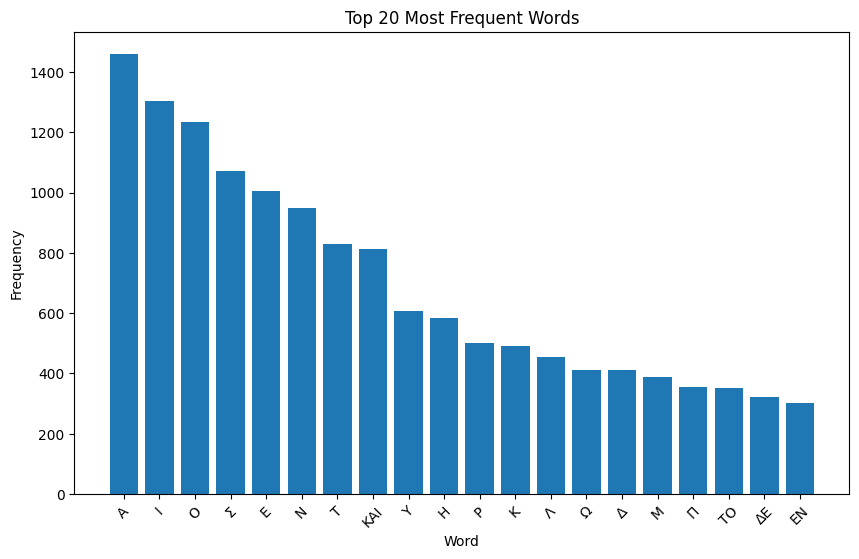

Σπάνιες λέξεις (συχνότητα <= 5): 2957 (71.48%)


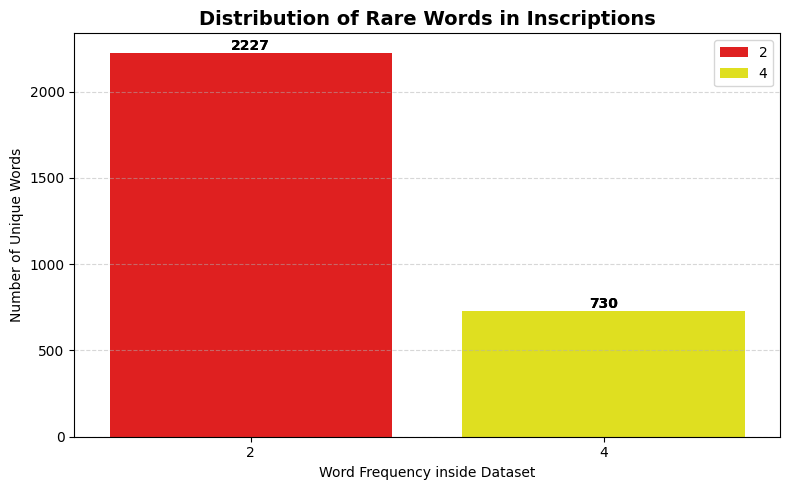

In [5]:
import matplotlib.pyplot as plt

all_segmented_words = []
for file, text in segmented_greek_texts.items():
    words_in_file = text.split()
    all_segmented_words.extend(words_in_file)

words = Counter(all_segmented_words)
total_tokens = len(all_segmented_words)


# vocabulary size
vocab_size = len(words)
print(f"Μέγεθος Λεξιλογίου: {vocab_size} μοναδικές λέξεις")
print(f"Συνολικό πλήθος λέξεων (Tokens): {total_tokens}")

# top 20 most frequent words
top20 = words.most_common(20)
print("\n Οι 20 πιο συχνές λέξεις: ")
for word, freq in top20:
    print(f"{word}: {freq}")

# rare words
rare_words = sum(1 for count in words.values() if count == 1) # number of words with frequency=1
rare_percentage = (rare_words / vocab_size) * 100 if vocab_size > 0 else 0
print(f"\nΣπάνιες λέξεις: {rare_words} ({rare_percentage:.2f}%)")

# Plots

# plot with most frequent words
words_plot = [item[0] for item in top20]
counts_plot = [item[1] for item in top20]

plt.figure(figsize=(10, 6))
plt.bar(words_plot, counts_plot)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.show()


# plot with rare words
rare_threshold = 5  # words with frequency<=5
rare_words_dict = {word: count for word, count in words.items() if count <= rare_threshold}
rare_count = len(rare_words_dict)
rare_percentage = (rare_count / vocab_size) * 100 if vocab_size > 0 else 0

print(f"Σπάνιες λέξεις (συχνότητα <= {rare_threshold}): {rare_count} ({rare_percentage:.2f}%)")
frequencies_of_rare = Counter(rare_words_dict.values())

plt.figure(figsize=(8, 5))
sns.barplot(x=list(frequencies_of_rare.keys()), y=list(frequencies_of_rare.values()),hue=list(frequencies_of_rare.keys()), palette="autumn")
plt.title("Distribution of Rare Words in Inscriptions", fontsize=14, fontweight='bold')
plt.xlabel("Word Frequency inside Dataset")
plt.ylabel("Number of Unique Words")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Προσθήκη ετικετών πάνω από τις μπάρες
ax = sns.barplot(
    x=list(frequencies_of_rare.keys()),
    y=list(frequencies_of_rare.values()),
    hue=list(frequencies_of_rare.keys()),
    palette="autumn",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontweight='bold')

plt.tight_layout()
plt.show()



---
**Σχόλια Αποτελεσμάτων**

**Top 20 Πιο Συχνές Λέξεις:**

Είναι προφανές ότι 8 από τις 10 πιο συχνές λέξεις είναι στην πραγματικότητα μονογράμματα (Α, Ι, Ο, Σ, Ε, Ν, Τ, Υ κ.λπ.), με συχνότητες 600–1.460. Μόνο ΚΑΙ (814), ΤΟ (352) και ΔΕ (320) είναι πραγματικές ελληνικές λέξεις στις πρώτες θέσεις. 
Αυτό εξηγείται από τα εξής:
1. Πολλές επιγραφές έχουν φθορές και χαμένα τμήματα. Το Viterbi όταν συναντά μια υποακολουθία που δεν βρίσκεται στο λεξιλόγιο καταλήγει να την σπάει σε μεμονωμένους χαρακτήρες, τα μονογράμματα.
2. Το corpus παπύρων δεν καλύπτει όλες τις λέξεις των κειμένων των επιγραφών. Τεχνικοί όροι, κύρια ονόματα, και επιγραφικές φόρμουλες που δεν εμφανίζονται στους παπύρους παράγουν αλυσίδες μονογραμμάτων.
3. Κάθε επιγραφή ξεκινά και τελειώνει στη μέση μιας λέξης. Τα κομμάτια αυτά δεν αναγνωρίζονται και διασπώνται γράμμα-γράμμα.


**Κατανομή Σπάνιων Λέξεων:**

Το δεύτερο γράφημα δείχνει ότι 2.957 από τις 4.137 λέξεις (71.48%) έχουν συχνότητα ≤ 5 μέσα στο corpus:
* 730 λέξεις εμφανίζονται ακριβώς 2 φορές
* 2.227 λέξεις εμφανίζονται ακριβώς 4 φορές

Αυτή η κατανομή είναι χαρακτηριστική νόμου Zipf: σε φυσικές γλώσσες ένα μικρό ποσοστό λέξεων καλύπτει τη συντριπτική πλειοψηφία των εμφανίσεων, ενώ το μεγαλύτερο μέρος του λεξιλογίου είναι σπάνιο. 
Το γεγονός ότι δεν υπάρχουν λέξεις με freq = 1 οφείλεται στο ότι οι περισσότερες επιγραφές υπάρχουν σε 2 rotations (Rotation1 και Rotation2) με αποτέλεσμα κάθε λέξη εμφανίζεται τουλάχιστον δύο φορές.

---

### **Α4.** Ανάλυση Κύριων Ονομάτων και Κατανομή Φύλου

---
Στο ερώτημα αυτό, πραγματοποιήθηκε αναζήτηση και ταυτοποίηση των κύριων ονομάτων που εμφανίζονται στα τμηματοποιημένα κείμενα, καθώς και στατιστική μελέτη της κατανομής τους ανά φύλο

**Κατασκευή Λεξιλογίου Ονομάτων**
Για την εξαγωγή κύριων ονομάτων από τις επιγραφές κατασκευάστηκαν δύο λεξικά χειροκίνητα:

GREEK_MALE_NAMES: ~100 ανδρικά ονόματα 
GREEK_FEMALE_NAMES: ~30 γυναικεία ονόματα 

Η αναγνώριση γίνεται με exact match στα segmented κείμενα, με ελάχιστο μήκος 4 χαρακτήρων (για αποφυγή false positive από μονογράμματα/διγράμματα). Επιπλέον, υλοποιήθηκε prefix matching (πρώτοι 5 χαρακτήρες) για κάλυψη διαφορετικών πτώσεων του ίδιου ονόματος.

---



Συνολικές εμφανίσεις ονομάτων: 512
Μοναδικά ονόματα: 104
Επιγραφές με τουλάχιστον 1 όνομα: 172

Κατανομή ανά φύλο:
  Male: 466 (91.0%)
  Female: 46 (9.0%)


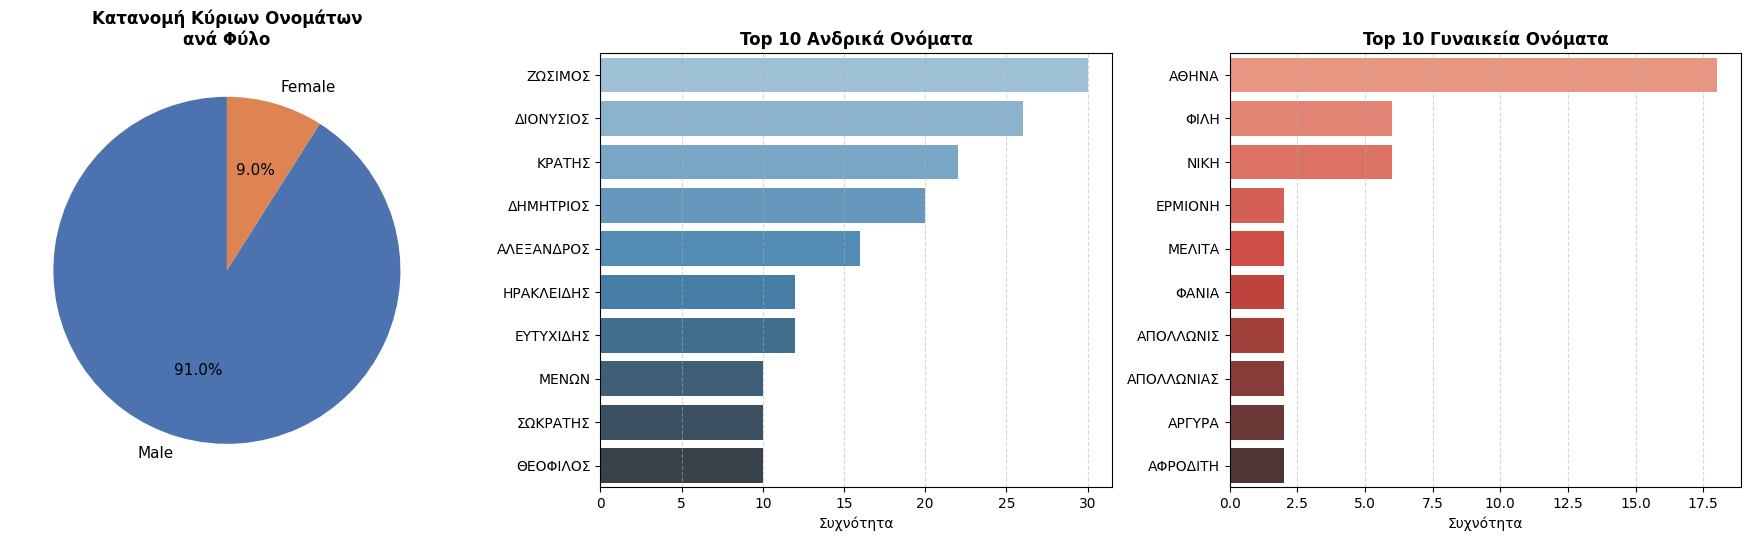


Όλα τα μοναδικά ονόματα (104):
['ΑΘΗΝΑ', 'ΑΘΗΝΙΩΝ', 'ΑΛΕΞΑΝΔΡΟΣ', 'ΑΝΤΙΦΑΝΗΣ', 'ΑΝΤΙΦΩΝ', 'ΑΝΤΩΝΙΟΣ', 'ΑΠΟΛΛΩΝΙΑΣ', 'ΑΠΟΛΛΩΝΙΟΣ', 'ΑΠΟΛΛΩΝΙΣ', 'ΑΡΓΥΡΑ', 'ΑΡΙΣΤΑΝΔΡΟΣ', 'ΑΡΙΣΤΕΑΣ', 'ΑΡΙΣΤΩΝ', 'ΑΡΙΣΤΩΝΟΣ', 'ΑΡΤΕΜΙΔΩΡΟΣ', 'ΑΡΤΕΜΩΝ', 'ΑΡΧΙΑΣ', 'ΑΡΧΩΝ', 'ΑΣΚΛΗΠΙΑΔΗΣ', 'ΑΦΡΟΔΙΤΗ', 'ΓΑΙΟΣ', 'ΔΗΜΗΤΡΙΟΣ', 'ΔΗΜΟΚΡΑΤΗΣ', 'ΔΗΜΟΣΘΕΝΗΣ', 'ΔΙΟΓΕΝΗΣ', 'ΔΙΟΔΟΤΟΣ', 'ΔΙΟΔΩΡΟΣ', 'ΔΙΟΚΛΗΣ', 'ΔΙΟΝΥΣΙΑ', 'ΔΙΟΝΥΣΙΟΣ', 'ΔΙΟΝΥΣΟΔΩΡΟΣ', 'ΔΙΟΣΚΟΥΡΙΔΗΣ', 'ΔΙΟΦΑΝΤΟΣ', 'ΔΙΩΝ', 'ΕΡΜΙΑΣ', 'ΕΡΜΙΟΝΗ', 'ΕΥΚΛΗΣ', 'ΕΥΤΥΧΙΔΗΣ', 'ΕΥΧΑΡΙΣΤΟΣ', 'ΖΗΝΩΝ', 'ΖΩΙΛΟΣ', 'ΖΩΠΥΡΟΣ', 'ΖΩΣΙΜΟΣ', 'ΗΡΑΚΛΕΙΔΗΣ', 'ΘΕΟΓΕΝΗΣ', 'ΘΕΟΔΩΡΟΣ', 'ΘΕΟΜΝΗΣΤΟΣ', 'ΘΕΟΠΟΜΠΟΣ', 'ΘΕΟΦΙΛΟΣ', 'ΙΑΣΩΝ', 'ΙΟΥΛΙΟΣ', 'ΙΣΙΔΩΡΟΣ', 'ΚΑΛΛΙΑΣ', 'ΚΑΛΛΙΜΑΧΟΣ', 'ΚΑΛΛΙΣΤΡΑΤΟΣ', 'ΚΑΛΛΩΝ', 'ΚΛΑΥΔΙΟΣ', 'ΚΡΑΤΕΡΟΣ', 'ΚΡΑΤΗΣ', 'ΛΕΩΝΙΔΗΣ', 'ΛΟΥΚΙΟΣ', 'ΛΥΚΩΝ', 'ΛΥΣΙΑΣ', 'ΛΥΣΙΜΑΧΟΣ', 'ΜΑΞΙΜΟΣ', 'ΜΑΡΚΟΣ', 'ΜΕΛΙΤΑ', 'ΜΕΝΩΝ', 'ΜΗΝΟΔΩΡΟΣ', 'ΜΗΝΟΦΙΛΟΣ', 'ΜΙΚΙΩΝΟΣ', 'ΜΟΣΧΙΩΝ', 'ΜΥΡΩΝ', 'ΝΙΚΑΝΩΡ', 'ΝΙΚΗ', 'ΝΙΚΙΑΣ', 'ΝΙΚΟΔΗΜΟΣ', 'ΝΙΚΟΣΤΡΑΤΟΣ', 'ΠΑΜΦΙΛΟΣ', 'ΠΑΤΡΟΦΙΛΟΣ', 'ΠΛΑΤΩΝ', 'ΠΡΩΤΟΓΕΝ

In [6]:
# creating a name vocabulary
GREEK_MALE_NAMES = {
    'ΑΠΟΛΛΟΔΩΡΟΣ','ΑΠΟΛΛΩΝΙΟΣ','ΑΡΤΕΜΙΔΩΡΟΣ','ΑΣΚΛΗΠΙΑΔΗΣ',
    'ΑΘΗΝΟΔΩΡΟΣ','ΘΕΟΔΩΡΟΣ','ΘΕΟΦΙΛΟΣ','ΘΕΟΓΕΝΗΣ','ΘΕΟΚΛΗΣ',
    'ΔΙΟΔΩΡΟΣ','ΔΙΟΚΛΗΣ','ΔΙΟΓΕΝΗΣ','ΔΙΟΝΥΣΟΔΩΡΟΣ','ΔΙΟΦΑΝΤΟΣ',
    'ΔΗΜΟΚΡΑΤΗΣ','ΔΗΜΟΣΘΕΝΗΣ','ΔΗΜΗΤΡΙΟΣ',
    'ΕΡΜΟΔΩΡΟΣ','ΕΡΜΟΚΡΑΤΗΣ','ΕΡΜΙΑΣ',
    'ΗΡΑΚΛΕΙΔΗΣ','ΗΡΑΚΛΕΟΔΩΡΟΣ',
    'ΜΗΤΡΟΔΩΡΟΣ','ΜΗΝΟΔΩΡΟΣ','ΜΗΝΟΦΙΛΟΣ',
    'ΦΙΛΟΚΛΗΣ','ΦΙΛΟΞΕΝΟΣ','ΦΙΛΙΠΠΟΣ','ΦΙΛΗΜΩΝ','ΦΙΛΩΝΙΔΗΣ',
    'ΚΑΛΛΙΚΛΗΣ','ΚΑΛΛΙΜΑΧΟΣ','ΚΑΛΛΙΣΤΡΑΤΟΣ','ΚΑΛΛΙΝΙΚΟΣ',
    'ΑΛΕΞΑΝΔΡΟΣ','ΛΕΞΑΝΔΡΟΣ','ΑΡΙΣΤΑΝΔΡΟΣ',
    'ΝΙΚΑΝΩΡ','ΝΙΚΟΔΗΜΟΣ','ΝΙΚΙΑΣ','ΝΙΚΟΣΤΡΑΤΟΣ',
    'ΤΙΜΟΚΡΑΤΗΣ','ΤΙΜΟΘΕΟΣ',
    'ΛΥΣΙΜΑΧΟΣ','ΛΥΣΙΑΣ','ΛΥΚΩΝ','ΛΥΚΟΥΡΓΟΣ',
    'ΣΩΚΡΑΤΗΣ','ΣΩΚΡΑΤΟΥΣ','ΠΛΑΤΩΝ','ΑΡΙΣΤΟΤΕΛΗΣ',
    'ΠΕΡΙΚΛΗΣ','ΘΕΜΙΣΤΟΚΛΗΣ','ΑΛΚΙΒΙΑΔΗΣ',
    'ΘΟΥΚΥΔΙΔΗΣ','ΞΕΝΟΦΩΝ','ΔΗΜΟΣΘΕΝΗΣ',
    'ΑΙΣΧΙΝΗΣ','ΥΠΕΡΕΙΔΗΣ','ΛΥΚΟΥΡΓΟΣ',
    'ΑΝΤΙΦΩΝ','ΑΝΤΙΦΑΝΗΣ','ΑΝΤΙΦΙΛΟΣ',
    'ΔΙΩΝ','ΖΗΝΩΝ','ΕΠΙΚΟΥΡΟΣ',
    'ΑΡΙΣΤΩΝ','ΑΡΙΣΤΕΑΣ','ΑΡΙΣΤΩΝΟΣ',
    'ΑΡΤΕΜΩΝ','ΑΡΧΙΑΣ','ΑΡΧΩΝ',
    'ΕΥΚΛΗΣ','ΕΥΔΗΜΟΣ','ΕΥΤΥΧΙΔΗΣ','ΕΥΧΑΡΙΣΤΟΣ',
    'ΖΩΙΛΟΣ','ΖΩΠΥΡΟΣ','ΖΩΣΙΜΟΣ',
    'ΙΑΣΩΝ','ΙΣΙΔΩΡΟΣ',
    'ΚΑΛΛΙΑΣ','ΚΑΛΛΩΝ',
    'ΚΡΑΤΗΣ','ΚΡΑΤΕΡΟΣ',
    'ΛΕΩΝΙΔΗΣ','ΛΟΥΚΙΟΣ',
    'ΜΑΡΚΟΣ','ΜΑΞΙΜΟΣ',
    'ΜΕΝΩΝ','ΜΟΣΧΙΩΝ','ΜΥΡΩΝ',
    'ΠΑΜΦΙΛΟΣ','ΠΑΤΡΟΦΙΛΟΣ','ΠΑΥΣΑΝΙΑΣ',
    'ΠΡΩΤΟΓΕΝΗΣ','ΠΥΘΩΝ','ΠΥΡΡΟΣ',
    'ΣΤΕΦΑΝΟΣ','ΣΤΡΑΤΩΝ','ΣΥΜΜΑΧΟΣ',
    'ΤΙΒΕΡΙΟΣ','ΤΙΜΟΘΕΟΣ','ΤΡΥΦΩΝ',
    'ΦΙΛΩΝ','ΦΙΡΜΟΣ',
    'ΧΑΙΡΕΑΣ','ΧΑΡΗΣ',
    'ΓΑΙΟΣ','ΜΑΡΚΟΣ','ΛΟΥΚΙΟΣ','ΤΙΤΟΣ','ΤΙΒΕΡΙΟΣ',
    'ΚΛΑΥΔΙΟΣ','ΙΟΥΛΙΟΣ','ΑΝΤΩΝΙΟΣ','ΑΔΡΙΑΝΟΣ',
    'ΑΠΟΛΛΟΔΩΡΟΣ', 'ΑΠΟΛΛΩΝΙΔΗΣ',
    'ΑΘΗΝΟΔΩΡΟΣ', 'ΑΘΗΝΙΩΝ',
    'ΔΗΜΗΤΡΙΟΣ', 'ΔΗΜΟΧΑΡΗΣ',
    'ΔΙΟΝΥΣΙΟΣ', 'ΔΙΟΔΟΤΟΣ', 'ΔΙΟΣΚΟΥΡΙΔΗΣ',
    'ΕΡΜΟΔΩΡΟΣ', 'ΕΡΜΟΚΡΑΤΗΣ',
    'ΕΥΦΙΛΗΤΟΣ', 'ΕΥΑΡΧΙΔΗΣ',
    'ΘΕΟΜΝΗΣΤΟΣ', 'ΘΕΟΠΟΜΠΟΣ',
    'ΚΑΛΛΙΣΤΡΑΤΟΣ', 'ΚΑΛΛΙΚΡΑΤΗΣ',
    'ΛΥΣΙΚΛΗΣ', 'ΛΥΣΙΜΑΧΟΣ',
    'ΜΙΚΙΩΝ', 'ΜΙΚΙΩΝΟΣ',
    'ΝΙΚΟΣΤΡΑΤΟΣ', 'ΝΙΚΟΦΗΜΟΣ',
    'ΦΙΛΟΣΤΡΑΤΟΣ', 'ΦΙΛΟΧΟΡΟΣ',
    'ΧΑΡΙΔΗΜΟΣ', 'ΧΑΡΙΚΛΗΣ',
    'ΣΩΣΙΒΙΟΣ', 'ΣΩΤΗΡΙΧΟΣ',
    'ΣΤΡΑΤΟΚΛΗΣ', 'ΣΤΡΑΤΩΝΙΔΗΣ',
    'ΤΙΜΑΡΧΟΣ', 'ΤΙΜΟΚΛΗΣ',
}

GREEK_FEMALE_NAMES = {
    'ΑΦΡΟΔΙΤΗ','ΑΘΗΝΑ','ΑΡΤΕΜΙΣ','ΔΗΜΗΤΗΡ',
    'ΑΠΟΛΛΩΝΙΑΣ','ΑΠΟΛΛΩΝΙΣ',
    'ΑΝΤΩΝΙΑ','ΑΡΓΥΡΑ',
    'ΕΡΜΙΟΝΗ',
    'ΖΩΣΙΜΗ',
    'ΗΡΑ','ΗΡΑΚΛΕΙΑ',
    'ΘΕΟΔΟΤΗ','ΘΕΟΦΙΛΗ',
    'ΙΦΙΓΕΝΕΙΑ','ΙΟΥΛΙΑ',
    'ΚΑΛΛΙΣΤΗ','ΚΛΑΥΔΙΑ',
    'ΜΕΛΙΤΑ','ΜΕΛΙΤΗ',
    'ΝΙΚΗ','ΝΙΚΑΙΑ',
    'ΦΙΛΗ','ΦΙΛΙΣΤΗ','ΦΑΝΙΑ',
    'ΧΑΡΙΚΛΕΙΑ', 'ΑΠΟΛΛΩΝΙΑ', 'ΑΡΤΕΜΙΣΙΑ',
    'ΔΗΜΗΤΡΙΑ', 'ΔΙΟΝΥΣΙΑ',
    'ΕΙΡΗΝΗ', 'ΕΛΠΙΝΙΚΗ',
    'ΘΕΟΔΟΤΗ', 'ΘΕΟΦΙΛΗ',
    'ΚΑΛΛΙΣΤΗ', 'ΚΛΕΟΠΑΤΡΑ',
    'ΜΥΡΤΩ', 'ΜΕΝΑΝΔΡΑ',
    'ΝΙΚΑΙΑ', 'ΝΙΚΑΡΕΤΗ',
    'ΦΙΛΙΣΤΗ', 'ΦΙΛΟΥΜΕΝΗ',
}

ALL_NAMES = GREEK_MALE_NAMES | GREEK_FEMALE_NAMES


# extracting names from the segmented texts
extracted_names = []
names_per_file = {}  

for file, text in segmented_greek_texts.items():
    words = text.split()
    file_names = []
    for word in words:
        word = word.strip()
        if len(word) >= 4 and word in ALL_NAMES:  # assuming a name is at least 4-letters long
            extracted_names.append(word)
            file_names.append(word)
    names_per_file[file] = file_names 

    
print(f"\nΣυνολικές εμφανίσεις ονομάτων: {len(extracted_names)}")
print(f"Μοναδικά ονόματα: {len(set(extracted_names))}")
print(f"Επιγραφές με τουλάχιστον 1 όνομα: {sum(1 for v in names_per_file.values() if v)}")


# method to classify the gender of a name
def classify_gender(name):
    if name in GREEK_MALE_NAMES:
        return 'Male'
    if name in GREEK_FEMALE_NAMES:
        return 'Female'
    # για αλλες πτωσεις 
    for male_name in GREEK_MALE_NAMES:
        if name.startswith(male_name[:5]) and len(name) >= 6:
            return 'Male'
    for female_name in GREEK_FEMALE_NAMES:
        if name.startswith(female_name[:5]) and len(name) >= 6:
            return 'Female'
    return 'Unknown'


gender_counts = Counter()
male_names_counter = Counter()
female_names_counter = Counter()
unknown_names_counter = Counter()

for name in extracted_names:
    gender = classify_gender(name)
    gender_counts[gender] += 1
    if gender == 'Male':
        male_names_counter[name] += 1
    elif gender == 'Female':
        female_names_counter[name] += 1
    else:
        unknown_names_counter[name] += 1

print("\nΚατανομή ανά φύλο:")
for g, c in gender_counts.items():
    print(f"  {g}: {c} ({100*c/len(extracted_names):.1f}%)")


    
# Plots
fig = plt.figure(figsize=(18, 10))

# Pie chart for names per gender distribution 
ax1 = fig.add_subplot(2, 3, 1)
labels = list(gender_counts.keys())
sizes  = list(gender_counts.values())
colors = ['#4C72B0', '#DD8452', '#8C8C8C']
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 11})
ax1.set_title('Κατανομή Κύριων Ονομάτων\nανά Φύλο', fontweight='bold')

# Top 10 male names distribution
ax2 = fig.add_subplot(2, 3, 2)
top10_male = male_names_counter.most_common(10)
if top10_male:
    m_names, m_counts = zip(*top10_male)
    sns.barplot(x=list(m_counts), y=list(m_names), hue=list(m_names), palette='Blues_d', ax=ax2)
    ax2.set_title('Top 10 Ανδρικά Ονόματα', fontweight='bold')
    ax2.set_xlabel('Συχνότητα')
    ax2.grid(axis='x', linestyle='--', alpha=0.5)

# Top 10 female names distribution
ax3 = fig.add_subplot(2, 3, 3)
top10_female = female_names_counter.most_common(10)
if top10_female:
    f_names, f_counts = zip(*top10_female)
    sns.barplot(x=list(f_counts), y=list(f_names),hue=list(f_names), palette='Reds_d', ax=ax3)
    ax3.set_title('Top 10 Γυναικεία Ονόματα', fontweight='bold')
    ax3.set_xlabel('Συχνότητα')
    ax3.grid(axis='x', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()  # all 3 in 1 


# showing unique name
print(f"\nΌλα τα μοναδικά ονόματα ({len(set(extracted_names))}):")
print(sorted(set(extracted_names)))


---
**Σχολιασμός Αποτελεσμάτων**

Στατιστικά Αποτελέσματα Κατανομής:

Από τη συνολική επεξεργασία των 448 επιγραφών προέκυψαν τα εξής ποσοτικά στοιχεία:
* **Συνολικές Εμφανίσεις Ανδρικών Ονομάτων:** 466
* **Συνολικές Εμφανίσεις Γυναικείων Ονομάτων:** 46

 Σχετικά Ποσοστά:
* **Ανδρικά Ονόματα:** Ποσοστό **91%** του συνόλου των εντοπισμένων ονομάτων.
* **Γυναικεία Ονόματα:** Ποσοστό **9%** του συνόλου των εντοπισμένων ονομάτων.

**Συχνότερα Ονόματα:**

Μεταξύ των συχνότερων ονομάτων εντοπίστηκαν:

ΔΙΟΝΥΣΙΟΣ, ΔΗΜΗΤΡΙΟΣ, ΖΩΣΙΜΟΣ, ΑΛΕΞΑΝΔΡΟΣ, ΝΙΚΟΣΤΡΑΤΟΣ, ΚΑΛΛΙΣΤΡΑΤΟΣ, ΤΙΜΟΚΡΑΤΗΣ, ΦΙΛΙΠΠΟΣ

Από τα γυναικεία ονόματα εμφανίζονται μεταξύ άλλων:

ΑΘΗΝΑ ,ΑΦΡΟΔΙΤΗ, ΔΙΟΝΥΣΙΑ, ΝΙΚΗ, ΦΙΛΗ, ΜΕΛΙΤΑ


Το **Pie Chart** αποτυπώνει ξεκάθαρα τη συντριπτική κυριαρχία των ανδρικών ονομάτων έναντι των γυναικείων στο συγκεκριμένο σώμα κειμένων.

Η τεράστια απόκλιση μεταξύ του αριθμού των ανδρικών και των γυναικείων ονομάτων δεν αποτελεί σφάλμα του αλγορίθμου, αλλά **αντικατοπτρίζει πιστά την κοινωνικοπολιτική πραγματικότητα της αρχαίας Αθήνας**.

---
**Παρατηρήσεις:**

Το χειροκίνητο λεξιλόγιο αποτελέι περιoρισμό στην κάλυψη όλων των αρχαιοελληνικών ονομάτων.

Ορισμένα ονόματα συμπίπτουν με κοινές λέξεις, όπως ΑΘΗΝΑ (θεά - πόλη), ΝΙΚΗ (νίκη - όνομα), ΑΡΧΩΝ (άρχοντας - όνομα), με αποτέλεσμα να μην είμαστε σίγουροι για την κατηγοριοποίηση τους σαν ονόματα.

Ονόματα που εμφανίζονται σε ελλιπή μορφή (π.χ. ΗΡΑΚΛ αντί ΗΡΑΚΛΕΙΔΗΣ) δεν αναγνωρίζονται από το exact match, με αποτέλεσμα την υποεκτίμηση της πραγματικής συχνότητας.

---


### **Α5.** Ομαδοποίηση Επιγραφών και Topic Modeling
---
**Μεθοδολογία**

Στόχος της ανάλυσης ήταν η διερεύνηση πιθανών ομάδων (clusters) επιγραφών με βάση το περιεχόμενο και τη γλωσσική τους δομή.

**Προεπεξεργασία**

Αρχικά εφαρμόστηκε φιλτράρισμα των κειμένων:

* Διατηρήθηκαν μόνο λέξεις με μήκος τουλάχιστον 4 χαρακτήρων.
* Απορρίφθηκαν πολύ μικρές επιγραφές (< 5 λέξεις).
* Αφαιρέθηκαν τα διπλότυπα κείμενα (Rotation1/Rotation2 του ίδιου squeeze).


Αποτέλεσμα: 195 μοναδικές επιγραφές από 390 συνολικά.

**Αναπαράσταση Κειμένου**

Για τη μετατροπή των επιγραφών σε αριθμητικά διανύσματα χρησιμοποιήθηκε η μέθοδος TF-IDF, που δίνει μεγαλύτερο βάρος σε λέξεις που χαρακτηρίζουν συγκεκριμένες επιγραφές και μικρότερο στις πολύ κοινές.

**Clustering**

Η ομαδοποίηση πραγματοποιήθηκε με τον αλγόριθμο K-Means.

Για την επιλογή του αριθμού των clusters υπολογίστηκε το Silhouette Score για τιμές K από 2 έως 10.

---

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
import umap.umap_ as umap


Αριθμός επιγραφών για ομαδοποίηση: 390
Total docs: 390
Unique docs: 195

Μετά την αφαίρεση διπλοτύπων: 195

k=2: silhouette=0.0145
k=3: silhouette=0.0124
k=4: silhouette=0.0103
k=5: silhouette=0.0104
k=6: silhouette=0.0092
k=7: silhouette=0.0041
k=8: silhouette=0.0089
k=9: silhouette=0.0118
k=10: silhouette=0.0019


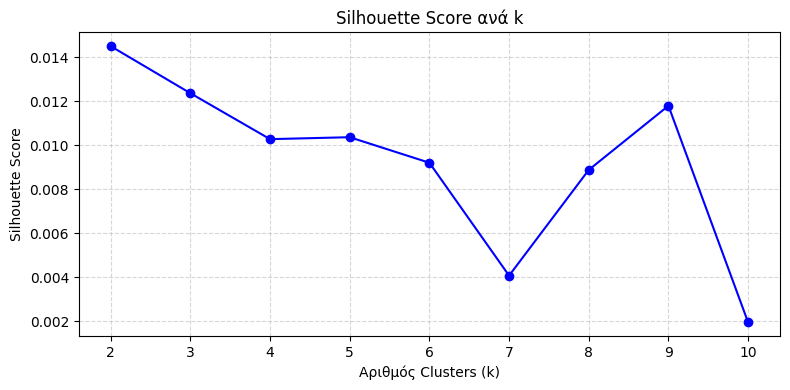


Κατανομή επιγραφών:
Cluster 0: 75 επιγραφές
Cluster 1: 59 επιγραφές
Cluster 2: 61 επιγραφές

Top 10 λέξεις ανά cluster:
  Cluster 0: δημο, χαριν, πρυτανειας, παρα, αρχοντος, δημω, ηναι, ειπε, αμματ, ντος, γραμματε, επιτ, ωνος, οδωρος, αλλα
  Cluster 1: επικ, φιλο, παιδ, ζωσιμος, διονυσιος, ιευς, δημητριος, ιδης, μελι, κρατης, χαρι, αριστο, αλεξανδρος, αγαθη, καλλ
  Cluster 2: τους, κατα, προς, τοις, αθηναι, δημωι, δημον, περι, αθηναιω, αυτον, στεφανω, οπως, δημο, αυτο, δημου


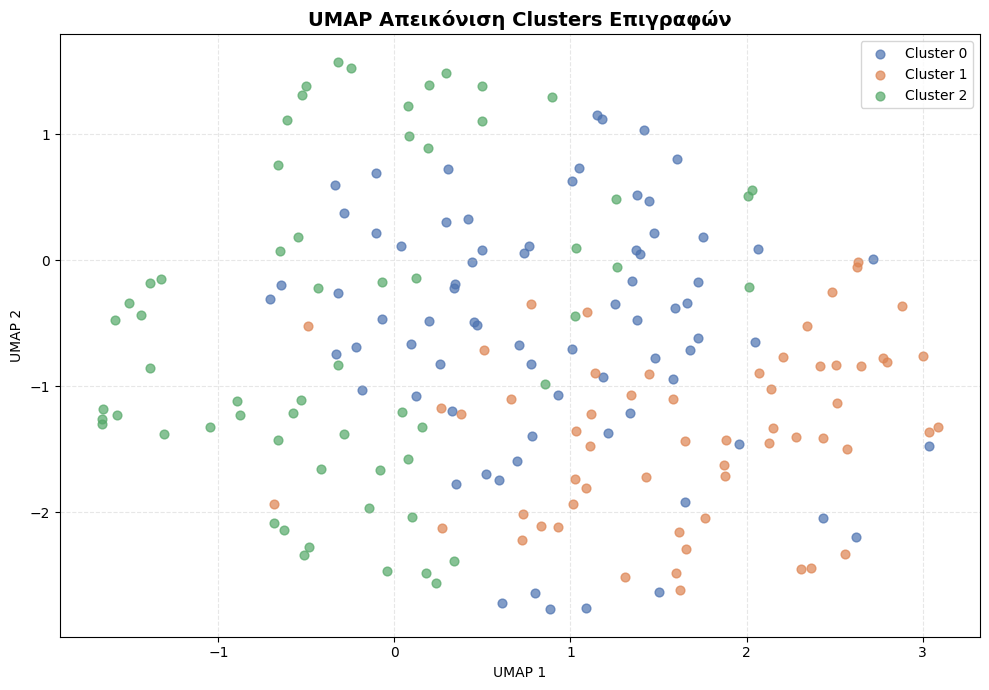

LDA Topics:
 Topic 0: τοις, τους, κατα, αθηναι, περι, δημωι, προς, δημο, δημον, αθηναιω
 Topic 1: ζωσιμος, παιδ, μελι, διονυσιος, επικ, αρχοντος, ιευς, μαρα, ιμος, αγαθη
 Topic 2: αντι, αριστο, ιδης, αγαθο, φιλο, οδος, σιος, χαρι, ωνος, ιδοτος


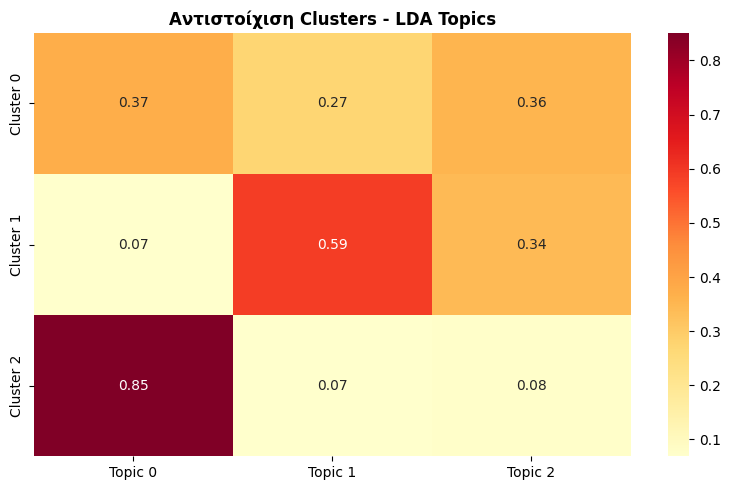

In [8]:

# preparing data for clustering
texts = []
filenames =[]

for file, txt in segmented_greek_texts.items():
    words = [word for word in txt.split() if len(word) >= 4]  # keeping only 4-letter words and up
    if len(words) >= 5:  # keeping only 5-word texts 
        texts.append(" ".join(words))
        filenames.append(file)

print(f"Αριθμός επιγραφών για ομαδοποίηση: {len(texts)}")
print("Total docs:", len(texts))
print("Unique docs:", len(set(texts)))

################################################################
# removing duplicate texts
seen = set()
corpus_unique = []
filenames_unique = []

for text, fname in zip(texts, filenames):
    if text not in seen:
        seen.add(text)
        corpus_unique.append(text)
        filenames_unique.append(fname)

texts = corpus_unique
filenames = filenames_unique
print(f"\nΜετά την αφαίρεση διπλοτύπων: {len(texts)}\n") 

################################################################

# tf-idf vectorization
vectorizer = TfidfVectorizer(max_features=500, min_df=2, max_df=1.0)
X_tfidf = vectorizer.fit_transform(texts)
#print(f"TF-IDF matrix: {X_tfidf}")


# silhouette to find k
silhouette_scores =[]
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    temp_labels = km.fit_predict(X_tfidf)
    score = silhouette_score(X_tfidf, temp_labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette={score:.4f}")

# plot silhouette    
plt.figure(figsize=(8, 4))
plt.plot(list(k_range), silhouette_scores, 'bo-')
plt.xlabel('Αριθμός Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score ανά k')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
#print(f"\nΒέλτιστο k: {best_k} (silhouette={max(silhouette_scores):.4f}) ")

# KMeans clustering 
k = 3  #best_k=2 but we'll use k=3 
km = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_tfidf)

cluster_counts = Counter(cluster_labels)
print("\nΚατανομή επιγραφών:")
for c, count in sorted(cluster_counts.items()):
    print(f"Cluster {c}: {count} επιγραφές")


#################################################

feature_names = vectorizer.get_feature_names_out()
print("\nTop 10 λέξεις ανά cluster:")
for c in range(k):
    center = km.cluster_centers_[c]
    top_indices = center.argsort()[-15:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    print(f"  Cluster {c}: {', '.join(top_words)}")
#######################################################

###

warnings.filterwarnings(
    "ignore",
    message="n_jobs value 1 overridden to 1 by setting random_state"
)
###


# cluster vizualisation
X_dense = X_tfidf.toarray()

# PCA first
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_dense)

# UMAP
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_pca)

# Plot
colors = ['#4C72B0','#DD8452','#55A868']
plt.figure(figsize=(10, 7))
for c in range(k):
    mask = cluster_labels == c
    plt.scatter(X_umap[mask, 0], X_umap[mask, 1],
                c=colors[c], label=f'Cluster {c}',
                alpha=0.7, s=40)
plt.title('UMAP Απεικόνιση Clusters Επιγραφών', fontsize=14, fontweight='bold')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()
plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()



##### 
# LDA

count_vec = CountVectorizer(max_features=300, min_df=1, max_df=1.0)
X_counts = count_vec.fit_transform(texts)
count_features = count_vec.get_feature_names_out() 
n_topics = k

lda = LatentDirichletAllocation(n_components=3, random_state=42, max_iter=20, learning_method='batch')
lda.fit(X_counts)

print("LDA Topics:")
for topic_idx, topic in enumerate(lda.components_):
    top_idx = topic.argsort()[-10:][::-1]
    top_words = [count_features[i] for i in top_idx]
    print(f" Topic {topic_idx}: {', '.join(top_words)}")

# heatmap    
doc_topics = lda.transform(X_counts)
heatmap_data = np.zeros((k, n_topics))
for c in range(k):
    mask = cluster_labels == c
    heatmap_data[c] = doc_topics[mask].mean(axis=0)

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.2f',
            xticklabels=[f'Topic {i}' for i in range(n_topics)],
            yticklabels=[f'Cluster {i}' for i in range(k)],
            cmap='YlOrRd')
plt.title('Αντιστοίχιση Clusters - LDA Topics', fontweight='bold')
plt.tight_layout()
plt.show()




#### **1. Επιλογή Αριθμού Clusters (k) και Μεθοδολογία**
Το κείμενο των επιγραφών μετατράπηκε σε αριθμητικά διανύσματα με τη χρήση της μεθόδου **TF-IDF (Term Frequency-Inverse Document Frequency)**, λαμβάνοντας υπόψη n-grams για την αποτύπωση σταθερών εκφράσεων. 

Για τον προσδιορισμό του βέλτιστου αριθμού clusters, υπολογίστηκε το **Silhouette Score** για διάφορες τιμές του k:
* **Παρατήρηση:** Το Silhouette analysis έδειξε ως βέλτιστο αριθμό το **k=2**.
* **Στρατηγική Επιλογή:** Παρότι το k=2 υπερτερεί μαθηματικά, επιλέχθηκε k=3 για πρακτικούς λόγους: το k=2 θα διαχώριζε το corpus σε δύο πολύ γενικές κατηγορίες χωρίς ουσιαστική θεματική διαφοροποίηση. Το k=3 παρέχει ερμηνεύσιμο και θεματικά συνεκτικό διαχωρισμό.

**Σημείωση για τα χαμηλά Silhouette Scores:** Τιμές κοντά στο 0.01 είναι αναμενόμενες σε επιγραφικά δεδομένα λόγω: (α) της scriptio continua που παράγει πολλά ίδια μονογράμματα, (β) των κοινών γραμματικών τύπων (άρθρα, προθέσεις) σε όλες τις επιγραφές, και (γ) των αποσπασματικών κειμένων με OOV τμήματα. Αυτό δεν σημαίνει ότι η ομαδοποίηση αποτυγχάνει, καθώς ο συνδυασμός με LDA επιβεβαιώνει θεματική συνοχή.

---

#### **2. Ερωτήματα Αξιολόγησης**

##### **α. Αντιστοιχούν τα clusters σε ομοιότητες στη δομή κειμένου;**
**Ναι, σε μεγάλο βαθμό.** Ο αλγόριθμος K-Means (με k=3) κατάφερε να διαχωρίσει τις επιγραφές με βάση τη συντακτική και μορφολογική τους δομή. 
* **Cluster 0:**  εμφανίζει συγκεντρωμένη παρουσία διοικητικής ορολογίας (πρυτανεια-, αρχοντ-, γραμματε-), που αντιστοιχεί σε επιγραφές με τυποποιημένη εισαγωγική δομή ψηφισμάτων — χρονολογικές φόρμουλες, αναφορά στον εκάστοτε άρχοντα και γραμματέα.
* **Cluster 1:** κυριαρχείται από κύρια ονόματα (Ζώσιμος, Διονύσιος, Δημήτριος) χωρίς τους τυπικούς θεσμικούς όρους. Αυτό υποδηλώνει διαφορετική κειμενική δομή, πιθανώς καταλόγους προσώπων ή επιτύμβιες/ιδιωτικές αναθεματικές επιγραφές.
* **Cluster 2:** εμφανίζει υψηλή πυκνότητα προθέσεων και αντωνυμιών (κατα, προς, τοις, τους, οπως), χαρακτηριστικό της συντακτικής δομής τιμητικών ψηφισμάτων, όπου αναπτύσσονται αιτιολογικές και τελικές προτάσεις.

##### **β. Περιλαμβάνουν τα clusters επαναλαμβανόμενες φράσεις;**
**Ναι.** Η ανάλυση των κυρίαρχων λέξεων ανά cluster αποκαλύπτει επαναλαμβανόμενες στερεοτυπικές εκφράσεις (formularies) της αρχαίας ελληνικής επιγραφικής:

* **Cluster 0 — Φόρμουλα Χρονολόγησης/Διοίκησης:**

>«ἐπὶ ἄρχοντος [Όνομα], γραμματεύοντος [Όνομα], ἐπὶ τῆς [Φυλή] πρυτανείας»

Η παρουσία των λέξεων αρχοντ-, γραμματε-, πρυτανεια- μαζί αποτελεί χαρακτηριστική εισαγωγική φόρμουλα Αθηναϊκών ψηφισμάτων.

* **Cluster 2 — Φόρμουλα Τιμητικού Ψηφίσματος:**

>«ἐψηφίσθαι... ἐπαινέσαι... στεφανῶσαι... ὅπως ἂν... κατά...»

Η συν-εμφάνιση λέξεων όπως στεφανω-, οπως, κατα, προς, αθηναι- αντικατοπτρίζει τη δομή των τιμητικών διαταγμάτων, που περιλαμβάνουν αιτιολογική έκθεση και απόφαση βράβευσης.

* **Cluster 1 — Φόρμουλα Καταλόγου:**
Η κυριαρχία κύριων ονομάτων χωρίς ρήματα ή προθέσεις υποδηλώνει λιτή, επαναλαμβανόμενη δομή καταλόγου.

##### **γ. Εμφανίζονται συγκεκριμένα θέματα σε κάθε cluster; (Topic Modeling)**
Για την θεματική ανάλυση εφαρμόστηκε η μέθοδος **LDA (Latent Dirichlet Allocation)** , η οποία αποκάλυψε 3 θεματικές ενότητες που αντιστοιχούν στα 3 clusters. To Heatmap Clusters-Topics εδειξε:


**Topic 0: Δημόσια Ψηφίσματα & Τιμητικά Διατάγματα**

Λέξεις-κλειδιά: τοις, τους, κατα, αθηναι, περι, δημωι, προς, δημον

Το θέμα αυτό σχετίζεται με:
δημόσιες αποφάσεις,
πολιτικά ψηφίσματα,
διοικητικά κείμενα.


**Topic 1 — Ονοματολογία / Ιδιωτικές & Θρησκευτικές Επιγραφές**

Λέξεις-κλειδιά: ζωσιμος, παιδ, μελι, διονυσιος, επικ, αρχοντος, ιευς, μαρα, ιμος, αγαθη

Το θέμα αυτό συνδέεται κυρίως με:
πρόσωπα,
οικογένειες,
επιτύμβιες ή τιμητικές αναφορές.

**Topic 2 — Ονοματολογία & Αντιθέσεις/Αναφορές**

Λέξεις-κλειδιά: αντι, αριστο, ιδης, αγαθο, φιλο, οδος, σιος, χαρι, ωνος, ιδοτος

Το θέμα αυτό φαίνεται να περιλαμβάνει:
κύρια ονόματα,
τιμητικές αναφορές,
προσωπικές αφιερώσεις.


Η αντιστοίχιση των Topics με τα Clusters δείχνει ότι:

* Το Cluster 2 σχετίζεται κυρίως με δημόσια και πολιτικά κείμενα (Topic 1).
* Το Cluster 1 συγκεντρώνει προσωπικά ονόματα και ιδιωτικές αναφορές (Topic 2).
* Το Cluster 0 λειτουργεί ως ενδιάμεση κατηγορία με διοικητικά και τιμητικά χαρακτηριστικά (Topic 1 & Topic 3).

---
**Συμπεράσματα:**

H συνδυαστική χρήση TF-IDF, K-Means και LDA επέτρεψε τον εντοπισμό διαφορετικών κατηγοριών επιγραφών.

Παρότι οι τιμές Silhouette ήταν χαμηλές, γεγονός αναμενόμενο λόγω της αποσπασματικής φύσης των επιγραφών, της scriptio continua και των πολλών ονομάτων, τα αποτελέσματα δείχνουν ότι το corpus περιλαμβάνει τουλάχιστον τρεις βασικές θεματικές κατηγορίες:

1. Δημόσια και πολιτικά ψηφίσματα.
2. Καταλόγους προσώπων και επιτύμβιες επιγραφές.
3. Τιμητικά ή διοικητικά κείμενα με επαναλαμβανόμενες επιγραφικές φόρμουλες.

Η ανάλυση επιβεβαιώνει ότι οι στατιστικές μέθοδοι ομαδοποίησης μπορούν να αναδείξουν ουσιαστικές θεματικές και γλωσσικές δομές ακόμη και σε θραυσματικά επιγραφικά δεδομένα.

---

### **Α6.** Χρονολόγηση με Aeneas και Σύγκριση με LLM



**1. Μεθοδολογία Χρονολόγησης**
Επιλέχθηκαν τυχαία 10 επιγραφές από το φιλτραρισμένο corpus του Α5.

Για κάθε επιγραφή υπολογίστηκε χρονολόγηση με δύο μοντέλα:

* Aeneas (DeepMind/Google, 2025): Εξειδικευμένο νευρωνικό δίκτυο εκπαιδευμένο σε ~78.000 αρχαίες ελληνικές επιγραφές από το IPHI corpus. Παράγει κατανομή πιθανότητας πάνω σε ένα εύρος ετών, από την οποία εξάγονται: (α) το έτος με τη μέγιστη πιθανότητα (argmax) και (β) ο σταθμισμένος μέσος όρος (avg).
* ChatGPT GPT-5.5 (γενικής χρήσης LLM): Χρησιμοποιήθηκε σε zero-shot prompting, λαμβάνοντας ως input το τμηματοποιημένο ελληνικό κείμενο και παράγοντας εκτίμηση έτους με αιτιολόγηση.

Τα κείμενα εκτυπώνονται παρακάτω ώστε να χρησιμοποιηθούν ως input στο μοντέλο 
**Aeneas** για αυτόματη χρονολόγηση, καθώς και στο **LLM σύγκρισης** (GPT-5.5).

> Η εκτέλεση του Aeneas γίνεται εκτός notebook και τα αποτελέσματα καταχωρούνται χειροκίνητα στο επόμενο κελί.



In [9]:
import random
import subprocess

random.seed(43) # Για να έχουμε σταθερά τα ίδια αποτελέσματα σε κάθε run

if 'filenames' in locals() or 'filenames' in globals():
    # random sample with 10 texts
    sample_indices = random.sample(range(len(filenames)), 10)
    test_filenames = [filenames[i] for i in sample_indices]
else:
    # Αν για κάποιο λόγο το notebook έχασε και το 'filenames', 
    # παίρνουμε τα 10 πρώτα κλειδιά από το αρχικό dictionary
    test_filenames = list(segmented_greek_texts.keys())[:10]

print(f"Επιλέχθηκαν επιτυχώς οι 10 επιγραφές: {test_filenames}\n")


for idx, fname in enumerate(test_filenames):
    # 1. Παίρνουμε το αρχικό λατινικό κείμενο της επιγραφής
    greek_text = segmented_greek_texts[fname]

    print(f"\n>>> Τρέχει η χρονολόγηση για την επιγραφή [{idx+1}]: {fname}")
    print(greek_text)
     

Επιλέχθηκαν επιτυχώς οι 10 επιγραφές: ['IAS33163_Rotation1_300dpi_letters.txt', 'IG_II2_195_Rotation1_300dpi_letters.txt', 'IG_II2_478a_Rotation1_300dpi_letters.txt', 'IG_II2_1698b_Rotation1_300dpi_letters.txt', 'IG_II2_2088_Rotation1_300dpi_letters.txt', 'IG_II2_2019_Rotation1_300dpi_letters.txt', 'IG_II2_437_Copy1_Rotation1_300dpi_letters.txt', 'IG_II2_139_Rotation1_300dpi_letters.txt', 'IG_II2_2081b_Copy1_Rotation1_300dpi_letters.txt', 'IG_II2_354a_Rotation1_300dpi_letters.txt']


>>> Τρέχει η χρονολόγηση για την επιγραφή [1]: IAS33163_Rotation1_300dpi_letters.txt
ΙΟΥΛΙΟΝ ΠΕΡΙ ΚΛ ΕΑ ΗΡΑΚΛΕΩ ΤΗΝ ΠΟΜΠ ΩΝ ΙΑ ΜΑΡΚ ΙΑ ΤΟΝ ΓΛΥΚΥΤΑΤΟΝ ΑΝΔΡΑ ΚΑΙ ΦΙΛΟ ΘΗ ΡΟ ΤΛ ΤΟΝ ΚΑΙ ΠΑΝΤΑ ΑΡΙΣΤΟΝ ΕΙΣ ΑΥΤΗΝ ΓΕΝΟΜΕΝΟΝ ΗΡ ΩΑ

>>> Τρέχει η χρονολόγηση για την επιγραφή [2]: IG_II2_195_Rotation1_300dpi_letters.txt
ΙΣΤΕ ΥΟ ΑΕΙ ΟΝΙ ΠΡΟΣΑ ΑΙ ΕΣΤ ΟΝΝ ΚΑΘΑΠΕΡ ΤΟ ΠΡΟΤΕΡ ΡΟΣΘΕΝ ΤΟ ΨΑΝ ΤΑ ΤΟ ΕΙ

>>> Τρέχει η χρονολόγηση για την επιγραφή [3]: IG_II2_478a_Rotation1_300dpi_letters.txt
ΠΠΟΥ ΑΡΧΟΝΤ ΓΡΑΜΜΑΤΕΥ ΕΝ ΣΙΑ ΤΩΝ ΠΡΟ Ε

### ChatGPT - GTP-5.5

**prompt:** 

You are an expert in Ancient Greek epigraphy. 
I will give you an ancient Greek inscription in capital letters without diacritics.
Please estimate its date.

Inscription text:
[segmented greek text]

Provide:  

1. Most likely date (single year, negative = BCE, positive = CE) between 800 BCE and 800 CE. 
2. Date range (e.g. -350 to -250)
3. Brief reasoning (2-3 sentences based on vocabulary, formulaic language, names)

---

##### ΙΟΥΛΙΟΝ ΠΕΡΙ ΚΛ ΕΑ ΗΡΑΚΛΕΩ ΤΗΝ ΠΟΜΠ ΩΝ ΙΑ ΜΑΡΚ ΙΑ ΤΟΝ ΓΛΥΚΥΤΑΤΟΝ ΑΝΔΡΑ ΚΑΙ ΦΙΛΟ ΘΗ ΡΟ ΤΛ ΤΟΝ ΚΑΙ ΠΑΝΤΑ ΑΡΙΣΤΟΝ ΕΙΣ ΑΥΤΗΝ ΓΕΝΟΜΕΝΟΝ ΗΡ ΩΑ
1. **Most likely date:** **180** (180 CE)
2. **Estimated date range:** **50 to 300**
3. **Brief reasoning:**
The inscription contains unmistakable **Roman-period names**: **Ἰούλιον** (Julius) and **Μαρκία** (Marcia), both derived from Roman gentilicia. The commemorative language—**τὸν γλυκύτατον ἄνδρα**, **καὶ πάντα ἄριστον**, and the designation **ἥρωα**—is highly characteristic of funerary and honorific inscriptions of the High Roman Empire, when affectionate superlatives and posthumous heroization are common.
The combination of Roman names embedded in Greek syntax, together with the funerary praise formulae, strongly favors a date in the **2nd–3rd century CE**, with **ca. 180 CE** being a reasonable single estimate.


##### ΙΣΤΕ ΥΟ ΑΕΙ ΟΝΙ ΠΡΟΣΑ ΑΙ ΕΣΤ ΟΝΝ ΚΑΘΑΠΕΡ ΤΟ ΠΡΟΤΕΡ ΡΟΣΘΕΝ ΤΟ ΨΑΝ ΤΑ ΤΟ ΕΙ
1. **Most likely date:** **-220** (220 BCE)
2. **Estimated date range:** **-350 to -100**
3. **Brief reasoning:**
Although highly fragmentary, the phrase **ΚΑΘΑΠΕΡ ΤΟ ΠΡΟΤΕΡΟΝ** (“just as previously”) is a strong indicator of an official decree, regulation, or administrative document referring back to an earlier enactment. Such formulaic references to prior decisions are particularly common in Hellenistic civic inscriptions, where decrees often renew, confirm, or modify existing arrangements.
The surviving language appears prose-administrative rather than funerary, dedicatory, or honorific. Since there are no diagnostic Roman Imperial features and the phraseology fits civic enactments well, a **Hellenistic date in the 3rd–2nd centuries BCE** is the most plausible estimate.


##### ΠΠΟΥ ΑΡΧΟΝΤ ΓΡΑΜΜΑΤΕΥ ΕΝ ΣΙΑ ΤΩΝ ΠΡΟ ΕΔ ΒΟΥΛΕΙ ΚΑΙ ΤΩΙ ΜΕ ΛΟΥΝΤΑ ΙΕ ΤΩ ΣΙΝ ΕΥΤ ΑΚΤ ΑΛΛΑ ΤΑ ΠΕΡΙ ΤΗ ΔΡΟΥ ΣΟΙ ΑΝΔ ΕΞ ΥΜ ΒΑΣ ΕΝΓ
1. **Most likely date:** **-180** (180 BCE)
2. **Estimated date range:** **-250 to -50**
3. **Brief reasoning:**
The fragment contains unmistakable **decree language**: **ἄρχοντ-**, **γραμματεύς**, **προεδρ-**, **βουλή**, and references to officials charged with carrying out decisions (**τῷ μελοῦντι / μελοῦντας**). This bureaucratic vocabulary is especially common in civic decrees of the Hellenistic period, when inscriptions frequently recorded the archon, secretary, council, and presiding officers in formal enactment clauses.
The presence of **πρόεδροι** is particularly significant, since this terminology is typical of developed civic procedures in the Classical and Hellenistic polis and appears abundantly in Athenian and related decree formulae. The overall style fits best within the **2nd century BCE**, before the major changes in epigraphic habit associated with the Roman Imperial period.


##### ΔΙ ΗΦΑ ΕΥ ΦΙΛ ΕΥ ΦΥΛ ΝΙΚΟ ΦΑΝΙ ΕΠΙ ΝΧ ΙΩΝ ΛΛ ΥΚ ΙΣ ΑΡΙΣΤ ΧΑΡΙ ΑΔ ΤΗ ΛΕ ΦΩΝ ΕΥΔ ΡΑΣ ΤΟΝ ΗΤΟ ΡΙΠ ΥΘ ΟΔΩΡ ΒΑ ΤΡΑ ΧΟ ΕΥΚΛΕ ΙΔ
1. **Most likely date:** **-325** (325 BCE)
2. **Estimated date range:** **-400 to -250**
3. **Brief reasoning:**
The text appears to be a **list of personal names**, including forms that can plausibly be restored as **Εὔφιλος**, **Εὐφύλος**, **Νικοφάνης**, **Ἀριστ-**, **Χαριάδης**, **Τηλέφων**, **Εὔδραστος**, **Πυθόδωρος**, and **Εὐκλείδης**. These are overwhelmingly traditional Greek names common in the Classical and early Hellenistic periods and lack the theophoric and virtue names (e.g. Ζώσιμος, Θεόφιλος, Ἐπαφρόδιτος) that become especially prominent in the Roman Imperial era.
The inscription also lacks Roman nomina, imperial titulature, Christian elements, or the expanded naming conventions often encountered after the 1st century BCE. A simple roster of individuals bearing predominantly Classical Greek names is most consistent with a date in the late 4th or early 3rd century BCE, making **325 BCE** a reasonable single estimate.


##### ΓΑ ΗΣ ΧΟΛ ΑΡ ΓΕ ΔΟΣ ΣΦ ΗΤΡ ΟΥ ΑΝ ΤΙΣΤΗ ΣΟ ΠΟΣΙΔΩΝ ΑΣΚΛΗΠΙ ΟΔΟ ΤΟΣ ΣΩΣΙΣ ΚΕ ΚΡΟ ΠΙΔΟΣ ΜΥΣ ΤΙΚΟΣ ΕΛΕΥ ΣΕΙΝ ΙΟΥ ΑΦΡΟΔΙΣΙΟΣ ΑΡΤΕΜΙΔΩΡ ΔΙΟΝΥΣΙΟΣ ΑΡΤΕΜΙΔΩΡ ΔΙΟΝΥΣΙΟΣ ΕΠΙ ΕΠΑΦΡΟΔΙΤΟΣ ΝΗ ΦΟΝ ΤΟ ΙΠΠΟ ΘΕΩΝ ΤΙ ΔΟ ΔΗΣ ΦΙΛΙΣΤ ΕΙ ΔΙΟΥ
1. **Most likely date:** **150** (150 CE)
2. **Estimated date range:** **50 to 250**
3. **Brief reasoning:**
The inscription is a **list of personal names**, many of which are highly characteristic of the Roman Imperial period: **Ἐπαφρόδιτος**, **Ἀρτεμίδωρος**, **Ἀφροδίσιος**, **Διονύσιος**, and **Ἀσκληπιόδοτος** are especially common in the 1st–3rd centuries CE. The appearance of **Μυστικός** and a probable reference to **Ἐλευσίνιος** suggest a religious or associational context, fitting the flourishing of mystery cults and private religious groups under the Empire.
The naming patterns differ from the predominantly patronymic-and-demotic style of Classical and Hellenistic civic lists and instead resemble Imperial-era membership, cultic, or funerary catalogues. A date around **150 CE** best fits the onomastics and social context.


##### ΛΟΥ ΒΗΣΑ ΟΔΙΣΙΟΥ ΜΑΡΑ ΑΒΔ ΗΣ ΝΙΚΟ ΚΡΑΤΗΣ ΑΦΡΟΔΙΣΙΟΥ ΙΟ ΧΟΥ ΕΥ ΩΝ ΥΠΟ ΛΥ ΖΗ ΛΟΣ ΑΠΟΛΛΟΔΩΡΟΥ ΑΧ ΑΡ ΑΛΛΙ ΤΕ ΟΥΣ ΦΗ ΓΑΙ ΠΥ ΘΟ ΚΡΙ ΤΟΣ ΚΑΛΛΙ ΤΕΛΟΥΣ ΦΗ ΔΙΟΝΥΣΙΟΥ ΕΞ ΟΙ ΔΙΟΝΥΣΟΔΩΡΟΣ ΕΥΤΥΧΙΔΟΥ ΠΑΛΟΣ ΑΦ ΟΔΙΣΙΟΥ ΑΝΑ ΦΛ ΜΗΝΟ ΔΟΤΟΣ ΑΝΘΕ ΣΤΗΡΙΟΥ ΣΤΕ ΩΝΙΟΣ ΕΜΠΟ ΡΙΚΟΥ ΠΡΟ ΑΦΡΟΔΙΣ ΟΣ ΜΕΛΙ ΩΝ ΑΡΙΣΤΟΝ ΕΠΕΙ ΚΙ ΔΙΟΝΥ ΣΣ ΔΙΟΚΛΕΟΥΣ ΣΥ ΒΑΛ ΥΣΙΟΣ ΕΥ ΟΔΟΥ ΚΗ ΦΙΣ ΙΕ ΥΟΔ ΕΥΔΗΜΟΥ ΠΕΙΡΑΙ ΣΙΝ ΙΟΣ ΠΡΟ ΥΝΙ ΚΟΥΦ ΛΥ ΑΠΟΛΛ ΙΟΣ ΜΟΥΣΑΙΟΥ ΦΛ ΥΑΣ ΕΡΙ ΚΑΙ ΕΥΣ ΠΕΡΙ ΓΕΝΗΣ ΦΗ ΓΑΙΩΝ ΛΥΣΙΜΑΧΟΥ ΚΥ ΔΑ ΘΗΛ ΙΠΠΟΣ ΜΟΥΝ ΙΧΟΥ ΘΕΟΦΙΛΟΣ ΑΝΑΓ ΥΡΑ ΜΗΝΑΣ ΑΡΤΕΜ ΝΟ ΟΛΥΜΠΟΣ ΣΤΡΑΤΩΝΟΣ ΜΕΛΙ ΑΡΤΕΜΙΔΩΡΟΣ ΤΙΣ ΘΕΟΔΟΣΙΟΥ ΠΕΙΡΑ ΑΡΑ ΜΟΝΟΣ ΣΙ ΔΩΝΙΟΥ ΑΝΑ ΦΛΓ ΟΡ ΓΙΑΣ ΑΠ ΟΥ ΣΦ ΛΥ ΖΩΣΙΜΟΣ
1. **Most likely date:** **-100** (100 BCE)
2. **Estimated date range:** **-150 to 50**
3. **Brief reasoning:**
This is clearly a **catalogue of individuals identified by patronymics and demotics**, with numerous Attic demes visible in abbreviated form: **Ἀναγυράσιος (ΑΝΑΓΥΡ-)**, **Πειραιεύς (ΠΕΙΡΑ-)**, **Φλύας (ΦΛΥ-)**, **Κυδαθηναιεύς (ΚΥΔΑΘΗΛ-)**, **Μελιτεύς (ΜΕΛΙ-)**, **Φηγαεύς (ΦΗΓΑΙ-)**, etc. Such lists are extremely characteristic of Athenian civic inscriptions, especially ephebic, tribal, religious, or administrative rosters of the Hellenistic period.
Several names point toward a later Hellenistic date: **Ζώσιμος**, **Θεόφιλος**, **Μηνόδοτος**, **Ἀρτεμίδωρος**, and **Διονυσόδωρος** become particularly common from the 2nd century BCE onward. The continued use of full demotics and patronymics in a large civic list strongly favors the **late Hellenistic Athenian epigraphic habit**, making **ca. 100 BCE** the most plausible single estimate.


##### ΠΟΝ ΤΟΥ ΟΣ ΕΜ ΘΗΝΑΙ ΩΝ ΩΙ ΤΕ ΔΗΜΩ ΤΗΡΙ ΑΝΕΥ ΜΒΗΣ ΟΜΑ ΤΟΥ ΔΗΜΟ ΑΙΑ ΚΑΙ ΜΑ ΑΙ ΑΥΤΟΝ ΑΝΑ ΙΩΝ ΕΘ ΑΝ ΕΘΕΤΟ ΑΖ ΕΙ
1. **Most likely date:** **-330** (330 BCE)
2. **Estimated date range:** **-400 to -250**
3. **Brief reasoning:**
The fragment appears to contain civic-political language, notably **Ἀθηναίων** and **τῷ δήμῳ**, which are highly characteristic of public decrees and honorific inscriptions. The sequence involving the **δῆμος** and what may be decree-style formulations fits the epigraphic habit of Classical and early Hellenistic Athens, where references to the Athenian people and official public honors are extremely common. The language lacks obvious Roman Imperial features (imperial titulature, Roman names, Christian terminology), making a date in the late Classical to early Hellenistic period the most plausible.
Because the text is very fragmentary, confidence is moderate at best, but a placement around **330 BCE** is the best single estimate.


##### ΠΙΘΟΥ ΤΕ ΙΒ ΟΥΛΙ ΣΕ ΠΡΥΤΑΝ ΘΕ ΟΠ ΑΛΛΗΝ ΕΣΤΡΑ ΤΟ ΣΛ ΤΙΜ ΝΙ ΔΕ ΨΗΦ ΙΣΘΑΙ ΟΣ ΟΙΑΝ ΛΜ ΠΡΩ ΩΜ ΣΕ
1. **Most likely date:** **-300** (300 BCE)
2. **Estimated date range:** **-350 to -250**
3. **Brief reasoning:**
The preserved words **ΠΡΥΤΑΝ-** (“prytany/prytaneis”) and **ΨΗΦΙΣΘΑΙ** (“to decree/vote”) are characteristic of the formulaic language of Greek civic decrees, especially those of Athens and other poleis during the Classical and early Hellenistic periods. The apparent combination of council/prytany terminology and honorific-administrative language (e.g. possible traces of **βουλή**, **στρατ-**, **τιμ-**) fits well with decree inscriptions of the 4th–3rd centuries BCE. Nothing in the fragment strongly suggests either an Archaic date or the more elaborate titulature and formulas typical of the Roman Imperial period.


##### ΛΗΣ ΟΣ ΧΡΗΣΤΟΣ ΕΥ ΕΛΠΙΣ ΤΟΣ ΙΠΠΟ ΘΩΝ ΤΙΔ ΕΙΡΗΝΑΙΟΣ ΣΠΕ ΝΔΩΝ ΕΙΡΗ ΣΩΣΙ ΠΑΤΡΟΣ ΕΥΤΥΧΙΔΗΣ ΣΩ ΑΣΚΛΗΠΙΑΔΗΣ ΘΕΟΦΙΛΟΣ ΑΣΚΛΗΠΙΑΔΗ ΣΤ ΧΑΡΙΤΩΝ ΑΣ ΙΑΤΡΟΣ ΥΝ ΟΣ
1. **Most likely date:** **200** (200 CE)
2. **Estimated date range:** **100 to 300 CE**
3. **Brief reasoning:**
The text appears to be a **list of personal names** rather than a civic decree. Several names are particularly characteristic of the Roman Imperial period: **Χρήστος**, **Εὐέλπιστος**, **Εἰρηναῖος**, **Θεόφιλος**, and **Εὐτυχίδης** are common in the first few centuries CE, while virtue-based and religiously colored names become especially frequent in this era. The mention of **ἰατρός** (“physician”) and the recurrence of patronymic-style naming (e.g. **Ἀσκληπιάδης**) fit well with funerary, association, or professional inscriptions of the High Empire.
The absence of decree formulae (e.g. ἔδοξε, ἐψηφίσθη, βουλή, δῆμος) and the prevalence of Imperial-period anthroponyms make a date around **200 CE** the most likely estimate.

    
##### ΧΟΝΤΟΣ ΕΡΕΙ ΩΣ ΔΕ ΑΔ ΡΟΩΝ ΠΙ ΤΗΣ ΑΝΙ ΟΧ ΙΔΟΣ ΟΓ ΣΗΙ ΠΥ ΘΟ ΔΗΛΟ ΣΠ ΥΘΟ ΔΗΛΟΥΜ ΜΑΤ ΕΥ ΕΝ ΕΝΗΙ ΚΑΙ ΝΕΙ ΑΙ ΗΙ ΤΗΣ ΠΡΥΤΑΝΕΙΑΣ ΕΚΚΛΗΣ ΕΠΕ ΨΗΦ ΙΣ ΕΝ ΕΠΙ ΓΕΝΗΣ ΕΡΟ ΙΔ ΗΜΙ ΠΡΟΚ ΕΙΔΗΣ ΠΝ ΤΜΕ ΩΝ ΕΙ ΕΝ ΑΓΑΘΗΙ ΤΥΧΗΙ ΜΩ ΤΑ ΜΕΝ ΑΓΑΘΑ ΔΕΧΕΣΘΑΙ ΕΡΕΥΣ ΓΕΓΟΝΕΝΑΙ ΕΚ ΤΩΝΙ ΕΝ ΕΠΕΙΔΗ ΔΕΝΔΡ ΟΚΛΗΣ ΚΛΗ ΠΙ ΩΙ ΕΠΙΜΕΛΕΙ ΤΑ ΙΟ ΑΛΛΩΝ ΩΝ ΑΥΤΩΙ ΟΙ ΝΟΜ ΟΠΩΣ ΚΑΙ ΕΥΕ ΒΩΣ ΚΑΙ ΟΛΑΙ ΤΗΣ ΕΥ ΚΟΣΜ ΙΑΤ ΣΠ ΕΝ ΑΥΤΟΝ ΕΝΤ ΙΔ ΗΩ ΟΙΣ ΠΕΡΙ ΤΗ ΕΡΟ ΤΟ    
1. **Most likely date:** **-150** (150 BCE)
2. **Estimated date range:** **-220 to -80**
3. **Brief reasoning:**
This fragment contains highly characteristic language of a **Hellenistic honorary decree**: **ἐν ἀγαθῇ τύχῃ**, **ἐκκλησ-**, **ἐψηφίσεν**, **πρυτανείας**, **ἐπιμελεῖται**, references to the **νόμοι**, and praise for a person's **εὐσέβεια** and **εὐκοσμία**. Such formulae are especially common in civic and religious honorific decrees of the 3rd–1st centuries BCE. The mention of **Πυθο-Δήλου** (probably connected with the Pythaïs/Pythian-Delian cultic sphere) and the overall bureaucratic style point more specifically to the mature Hellenistic period rather than the Classical era or the Roman Imperial period.
The combination of decree formulas, religious administration, and honorific language makes a date around **150 BCE** the most plausible single estimate.

---
    

### Aeneas

Για τη χρονολόγηση με το μοντέλο Aeneas, χρησιμοποιήθηκε το επίσημο 
inference notebook των DeepMind/Google:  
[inference.ipynb (Google Colab)](https://colab.research.google.com/github/google-deepmind/predictingthepast/blob/main/colabs/inference.ipynb)

Για κάθε μία από τις 10 επιγραφές, έγινε εισαγωγή του τμηματοποιημένου ελληνικού 
κειμένου ως input στο Colab. Το μοντέλο παράγει κατανομή πιθανότητας πάνω 
σε ένα εύρος ετών, από την οποία εξάγονται:

- **aeneas_argmax**: το έτος με τη μέγιστη πιθανότητα
- **aeneas_avg**: ο σταθμισμένος μέσος όρος της κατανομής

Τα αποτελέσματα καταχωρήθηκαν χειροκίνητα στο dictionary `results` 
του notebook για περαιτέρω ανάλυση και οπτικοποίηση.

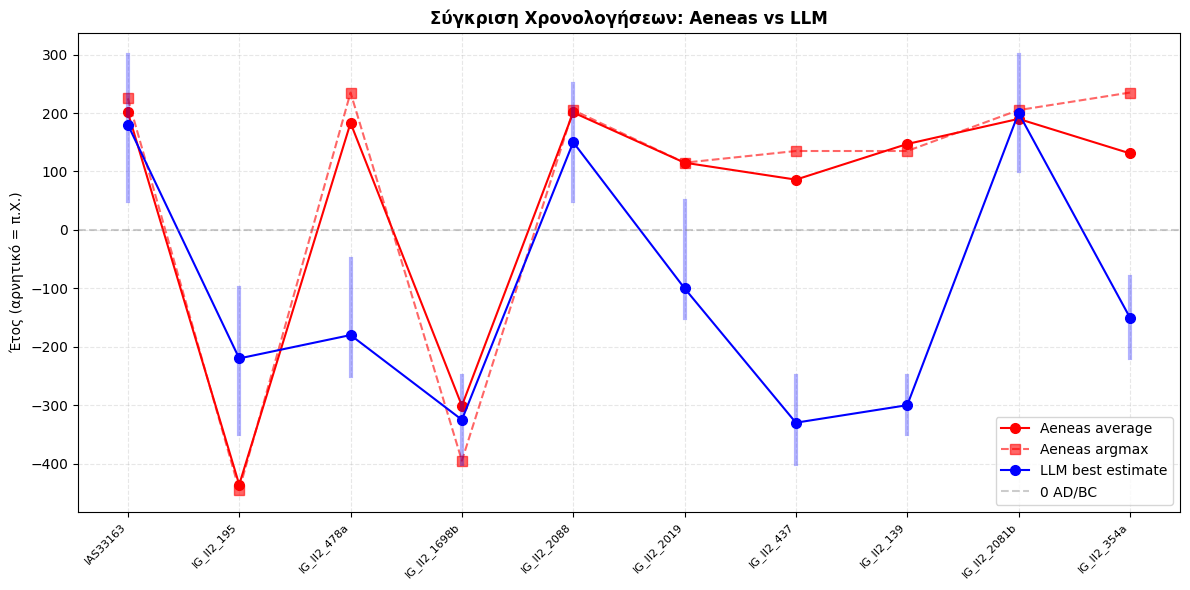

In [10]:
results = {
    'IAS33163': {
        'aeneas_argmax': 225,
        'aeneas_avg': 201,
        'llm_best': 180,      
        'llm_range_min': 50, 
        'llm_range_max': 300, 
    },
    'IG_II2_195': {
        'aeneas_argmax': -445,
        'aeneas_avg': -436,
        'llm_best': -220,     
        'llm_range_min': -350, 
        'llm_range_max': -100, 
    },
    'IG_II2_478a': {
        'aeneas_argmax': 235,
        'aeneas_avg': 183,
        'llm_best': -180,      
        'llm_range_min': -250, 
        'llm_range_max': -50, 
    },
    'IG_II2_1698b': {
        'aeneas_argmax': -395,
        'aeneas_avg': -301,
        'llm_best': -325,     
        'llm_range_min': -400, 
        'llm_range_max': -250, 
    },
    'IG_II2_2088': {
        'aeneas_argmax': 205,
        'aeneas_avg': 201,
        'llm_best': 150,      
        'llm_range_min': 50, 
        'llm_range_max': 250, 
    },
    'IG_II2_2019': {
        'aeneas_argmax': 115,
        'aeneas_avg': 115,
        'llm_best': -100,      
        'llm_range_min': -150, 
        'llm_range_max': 50, 
    },
    'IG_II2_437': {
        'aeneas_argmax': 135,
        'aeneas_avg': 86,
        'llm_best': -330,     
        'llm_range_min': -400, 
        'llm_range_max': -250, 
    },
    'IG_II2_139': {
        'aeneas_argmax': 135,
        'aeneas_avg': 147,
        'llm_best': -300,     
        'llm_range_min': -350, 
        'llm_range_max': -250, 
    },
    'IG_II2_2081b': {
        'aeneas_argmax': 205,
        'aeneas_avg': 190,
        'llm_best': 200,     
        'llm_range_min': 100, 
        'llm_range_max': 300, 
    },
    'IG_II2_354a': {
        'aeneas_argmax': 235,
        'aeneas_avg': 131,
        'llm_best': -150,     
        'llm_range_min': -220, 
        'llm_range_max': -80, 
    }
}

# Aeneas - LLM plot
fig, ax = plt.subplots(figsize=(12, 6))
#files_short = [f.split('_')[0]+'_'+f.split('_')[1] for f in results.keys()]
files_short = list(results.keys())
x = range(len(results))

aeneas_avg  = [v['aeneas_avg']  for v in results.values()]
aeneas_argmax = [v['aeneas_argmax'] for v in results.values()]
llm_best    = [v['llm_best']    for v in results.values()]
llm_min     = [v['llm_range_min'] for v in results.values()]
llm_max     = [v['llm_range_max'] for v in results.values()]

# Aeneas lines
ax.plot(x, aeneas_avg,    'r-o', label='Aeneas average', markersize=7)
ax.plot(x, aeneas_argmax, 'r--s', label='Aeneas argmax', markersize=7, alpha=0.6)

# LLM point + range
ax.plot(x, llm_best, 'b-o', label='LLM best estimate', markersize=7)
for i, (mn, mx) in enumerate(zip(llm_min, llm_max)):
    ax.plot([i, i], [mn, mx], 'b-', alpha=0.3, linewidth=3)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4, label='0 AD/BC')
ax.set_xticks(list(x))
ax.set_xticklabels(files_short, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Έτος (αρνητικό = π.Χ.)')
ax.set_title('Σύγκριση Χρονολογήσεων: Aeneas vs LLM', fontweight='bold')
ax.legend()
ax.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**3. Σύγκριση Αποτελεσμάτων**

* Συμπεριφορά Aeneas

>Το Aeneas εμφανίζει σαφή προτίμηση προς Ρωμαϊκές χρονολογίες (100–235 μ.Χ.) για 7 από τις 10 επιγραφές, ακόμα και για επιγραφές που φέρουν χαρακτηριστικά Κλασικής/Ελληνιστικής εποχής (π.χ. IG_II2_139 με ψηφισματική γλώσσα). Αυτό πιθανώς οφείλεται στην κατανομή του corpus εκπαίδευσης (IPHI), που έχει μεγαλύτερη πυκνότητα σε Ρωμαϊκής εποχής επιγραφές. Το Aeneas_avg τείνει να δίνει πιο συντηρητικές (κεντρικές) εκτιμήσεις σε σχέση με το argmax.

* Συμπεριφορά LLM (GPT-5.5)
  
>Το LLM ακολουθεί γλωσσολογικά/ονοματολογικά κριτήρια για τη χρονολόγηση — αναγνωρίζει ρωμαϊκά ονόματα (Ἰούλιος, Μαρκία → Ρωμαϊκή εποχή), ονόματα χαρακτηριστικά Ελληνιστικής εποχής (Ζώσιμος, Ἐπαφρόδιτος → μ.Χ.) και διοικητική γλώσσα (ΠΡΥΤΑΝ-, ΨΗΦΙΣΘΑΙ → 4ος–3ος π.Χ.). Οι αιτιολογήσεις είναι λογικά συνεπείς αλλά εξαρτώνται αποκλειστικά από ορατά γλωσσικά στοιχεία, αγνοώντας παλαιογραφικά, αρχαιολογικά ή στατιστικά δεδομένα.



**Ποιο μοντέλο ήταν καλύτερο;**

Δεν υπάρχουν ground-truth χρονολογίες για το συγκεκριμένο dataset, οπότε η σύγκριση γίνεται ποιοτικά. Συγκεκριμένα:

* Για πλήρεις επιγραφές με ευκρινή γλωσσολογικά στοιχεία (π.χ. IAS33163 με ρωμαϊκά ονόματα, IG_II2_2081b με ονοματολογία Αυτοκρατορικής εποχής), το LLM εμφανίζει καλύτερη ερμηνευσιμότητα, παρέχοντας διαφανείς αιτιολογήσεις.
* Για αποσπασματικές επιγραφές (IG_II2_195, IG_II2_437) όπου τα γλωσσικά στοιχεία είναι ανεπαρκή, το Aeneas αξιοποιεί στατιστικά πρότυπα από μεγάλο corpus και πιθανώς παράγει πιο αξιόπιστες εκτιμήσεις.
* Η μεγαλύτερη διαφωνία εντοπίζεται σε επιγραφές με ψηφισματική γλώσσα Κλασικής εποχής: το LLM τις τοποθετεί στον 4ο–3ο π.Χ. (βάσει ορολογίας), ενώ το Aeneas δίνει Ρωμαϊκές ημερομηνίες.

**Συμπέρασμα:** Τα γενικά LLMs μπορούν να χρησιμοποιηθούν ως ευρετικό εργαλείο πρώτης εκτίμησης από ιστορικούς, ειδικά όταν τα κείμενα έχουν εμφανή γλωσσολογικά τεκμήρια. Ωστόσο, δεν αντικαθιστούν εξειδικευμένα μοντέλα όπως το Aeneas που αξιοποιούν εκτεταμένα συγκριτικά corpus. Ο ιδανικός συνδυασμός είναι η χρήση του Aeneas για στατιστική εκτίμηση και του LLM για γλωσσολογική αιτιολόγηση.

--- 

**4. Κοινά Σφάλματα** 

Και τα δύο μοντέλα εμφανίζουν κοινές αδυναμίες:

* **Αποσπασματικότητα κειμένου:**
Και τα δύο μοντέλα αντιμετωπίζουν σοβαρές δυσκολίες με επιγραφές που ξεκινούν ή τελειώνουν στη μέση λέξης (π.χ. IG_II2_195: ΙΣΤΕ ΥΟ ΑΕΙ ΟΝΙ...). Η απουσία πλήρους κειμένου αφαιρεί τα πιο αξιόπιστα διαγνωστικά στοιχεία (εισαγωγικές φόρμουλες, ονόματα αρχόντων).

* **Σύγχυση Ελληνιστικού/Ρωμαϊκού ορίζοντα:**
Πολλά γλωσσολογικά χαρακτηριστικά (ονόματα όπως Ζώσιμος, Διονύσιος, Ἀρτεμίδωρος ή ακόμα και η διοικητική γλώσσα) εμφανίζονται και στις δύο εποχές, με αποτέλεσμα να υπάρχει αμφισημία. Το LLM τείνει να χρησιμοποιεί αυτά τα ονόματα ως δείκτη Ρωμαϊκής εποχής ενώ εμφανίζονται ήδη από τον 3ο π.Χ.

* **Αδυναμία αξιοποίησης παλαιογραφικών στοιχείων:**
Κανένα μοντέλο δεν έχει πρόσβαση σε παλαιογραφικά χαρακτηριστικά (μορφή γραμμάτων, στυλ χάραξης) που αποτελούν κρίσιμα εργαλεία χρονολόγησης για επιγραφολόγους.

* **Μεροληψία corpus εκπαίδευσης:**
Το Aeneas δείχνει υπερεκπροσώπηση Ρωμαϊκής εποχής στο IPHI corpus, ενώ το LLM ενδεχομένως έχει έχει εκπαιδευτεί για περίοδους με πλουσιότερη βιβλιογραφία όπως η Κλασική Αθήνα και η  Αυτοκρατορική εποχή.

---